# ETS MARL — Sweep Analysis

Counter-part to `scripts/sweep.py`. This notebook is **analysis-only** —
it does not train or instantiate the environment. It loads the CSV logs
produced by a sweep run (typically on Azure) and supports two complementary
modes of investigation:

1. **Top-level comparison across all variants and seeds** — price,
   reward, investment, compliance, secondary market, and newer
   diagnostics over training.
2. **Single-run deep-dive** — pick one `(variant, seed)` and reproduce
   the detailed D / A analysis from `Full Run & Analysis.ipynb` for
   that single run, with the green-investing and collateral-only
   sections removed and collateral folded into the reward
   decomposition panel.


In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup — Locate Project Root

No training, no environment construction. We only need access to `src/` for a few helpers (paths, optional eval) and to the `configs/` and `results/` folders.


In [2]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "configs"))

_candidates = ["..", ".", os.path.join("..", ".."),
               os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"), "Thesis-Energy-Auction"]
_found = _is_project_root(".")
if not _found:
    for _c in _candidates:
        if _is_project_root(_c):
            os.chdir(_c); _found = True; break
if not _found:
    raise FileNotFoundError(f"Cannot find project root (needs src/ + configs/).\nCWD: {os.getcwd()}  |  Contents: {os.listdir('.')}")

PROJECT_ROOT = Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
RESULTS_DIR = PROJECT_ROOT / "results"
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {PROJECT_ROOT}")
print(f"Config path: {CONFIG_PATH}")


Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
Config path: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\default.yaml


## 2. Imports


In [3]:
import os
import re
import yaml
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 3. Load the Sweep Specification

Point `SWEEP_SPEC` at the YAML you launched the sweep with. The sweep
launcher (`scripts/sweep.py`, see `src/utils/sweep.py` for schema)
deep-merges each variant's `overrides` onto the `base_config` and writes
results under `<output_dir>/<variant_name>/`, with filenames tagged by
`--run-tag <variant>` to keep them unique.


In [4]:
SWEEP_SPEC = PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml'
OUTPUT_DIR_OVERRIDE = PROJECT_ROOT / "results" / "sweeps" / "default"  # files live directly here (no variant subfolder)

from src.utils.sweep import load_sweep_spec, expand_dotted_overrides, deep_merge
spec = load_sweep_spec(str(SWEEP_SPEC))
with open(spec['base_config'], encoding='utf-8') as f:
    base_cfg = yaml.safe_load(f)
output_dir = Path(OUTPUT_DIR_OVERRIDE) if OUTPUT_DIR_OVERRIDE is not None else (PROJECT_ROOT / spec['output_dir']).resolve()

print(f'Sweep spec        : {SWEEP_SPEC}')
print(f'Base config       : {spec["base_config"]}')
print(f'Output dir        : {output_dir}   (exists={output_dir.exists()})')
print(f'Default seeds     : {spec["seeds"]}')
print(f'parallel_workers  : {spec["parallel_workers"]}')
print(f'threads_per_worker: {spec["threads_per_worker"]}')
print(f'#variants         : {len(spec["variants"])}')


Sweep spec        : C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\sweeps\default_seeds.yaml
Base config       : configs/default.yaml
Output dir        : C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\sweeps\default   (exists=True)
Default seeds     : [1729, 8191, 6561, 5041]
parallel_workers  : 4
threads_per_worker: None
#variants         : 1


### 3a. Variant matrix

Flatten each variant's overrides into a single row so the differences are immediately visible.


In [5]:
def _flatten_overrides(d, prefix=''):
    out = {}
    for k, v in d.items():
        key = f'{prefix}.{k}' if prefix else k
        if isinstance(v, dict): out.update(_flatten_overrides(v, key))
        else: out[key] = v
    return out

rows = []
for v in spec['variants']:
    seeds = v['seeds'] if v['seeds'] is not None else spec['seeds']
    flat = _flatten_overrides(expand_dotted_overrides(v.get('overrides') or {}))
    rows.append({'variant': v['name'], 'n_seeds': len(seeds), 'seeds': seeds, **flat})
variants_df = pd.DataFrame(rows).fillna('—')
variants_df


,variant,n_seeds,seeds
0,default,4,"[1729, 8191, 6561, 5041]"


## 4. Discover Runs

For every `(variant, seed)` pair we look for the per-episode CSV and the
per-year CSV. The sweep launcher writes them with a `--run-tag <variant>`
infix; older single-config runs and locally-run smoke tests do not. We
try the tagged filename first and fall back to the untagged one.


In [6]:
from src.utils.run_data import log_exists, default_ep_columns, default_yr_columns
def _resolve_run_files(variant_name, seed, variant_dir, output_dir):
    """Return (training_log_path_or_None, year_log_path_or_None). Search variant_dir then output_dir; tagged then untagged."""
    search_dirs = [d for d in (variant_dir, output_dir) if d is not None]
    training_names = [f"training_log_{variant_name}_s{seed}.csv", f"training_log_s{seed}.csv"]
    year_names = [f"year_log_{variant_name}_s{seed}.csv", f"year_log_s{seed}.csv"]
    tlog = ylog = None
    for base_dir in search_dirs:
        if tlog is None:
            for tname in training_names:
                cand = base_dir / tname
                if log_exists(cand): tlog = cand; break
        if ylog is None:
            for yname in year_names:
                cand = base_dir / yname
                if log_exists(cand): ylog = cand; break
        if tlog is not None and ylog is not None: break
    return tlog, ylog

discovery = []
for v in spec["variants"]:
    seeds = v["seeds"] if v["seeds"] is not None else spec["seeds"]
    variant_dir = output_dir / v["name"]
    for seed in seeds:
        tlog, ylog = _resolve_run_files(v["name"], seed, variant_dir, output_dir)
        discovery.append({
            "variant": v["name"], "seed": seed, "variant_dir": str(variant_dir),
            "training_log": str(tlog) if tlog else None, "year_log": str(ylog) if ylog else None,
            "has_training_log": tlog is not None, "has_year_log": ylog is not None,
            "found": (tlog is not None) or (ylog is not None),
        })

discovery_df = pd.DataFrame(discovery)
n_any = int(discovery_df["found"].sum())
n_train = int(discovery_df["has_training_log"].sum())
n_year = int(discovery_df["has_year_log"].sum())
print(f"Found any log for {n_any} / {len(discovery_df)} (variant, seed) pairs.")
print(f"  training logs: {n_train}")
print(f"  year logs    : {n_year}")
discovery_df


Found any log for 4 / 4 (variant, seed) pairs.
  training logs: 4
  year logs    : 4


,variant,seed,variant_dir,training_log,year_log,has_training_log,has_year_log,found
0,default,1729,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,True,True,True
1,default,8191,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,True,True,True
2,default,6561,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,True,True,True
3,default,5041,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...,True,True,True


### 4a. Load all available runs into memory

We also resolve each variant's effective config (base ⊕ overrides) so deep-dive cells can read e.g. `companies.n_agents`.


In [7]:
from tqdm.auto import tqdm


def _resolve_variant_config(variant):
    return deep_merge(base_cfg, expand_dotted_overrides(variant.get('overrides') or {}))

# Project both logs onto the analysis-superset columns at load time. The
# year_log carries 270+ diagnostic columns; pulling only the ~80 actually
# used by this notebook cuts in-RAM size by ~5-10x. Unknown columns are
# silently dropped by load_run_csv, so the same projection works across
# schema variants.
EP_COLUMNS = default_ep_columns()
YR_COLUMNS = default_yr_columns()

def _load_csv_or_none(path, columns=None):
    if path is None or (isinstance(path, float) and pd.isna(path)):
        return None
    return load_run_csv(path, columns=columns)

def _empty_ep_df(from_yr_df=None):
    if from_yr_df is not None and 'episode' in from_yr_df.columns:
        return pd.DataFrame({'episode': np.sort(from_yr_df['episode'].dropna().unique())})
    return pd.DataFrame({'episode': pd.Series(dtype='int64')})

def _empty_yr_df(from_ep_df=None):
    if from_ep_df is not None and 'episode' in from_ep_df.columns and len(from_ep_df) > 0:
        return pd.DataFrame({'episode': from_ep_df['episode'].astype('int64').values,
                             'year': np.zeros(len(from_ep_df), dtype='int64')})
    return pd.DataFrame({'episode': pd.Series(dtype='int64'), 'year': pd.Series(dtype='int64')})

variant_configs = {v['name']: _resolve_variant_config(v) for v in spec['variants']}
runs = {}

# Load complete runs first so deep-dive default (next(iter(runs))) is more likely valid.
discovery_sorted = sorted(discovery,
    key=lambda r: (r['has_training_log'] and r['has_year_log'], r['has_training_log'], r['has_year_log']),
    reverse=True)

for row in tqdm(discovery_sorted, desc='Loading sweep CSVs', unit='run', leave=True):
    if not row['found']:
        continue
    ep_df = _load_csv_or_none(row['training_log'], columns=EP_COLUMNS)
    yr_df = _load_csv_or_none(row['year_log'], columns=YR_COLUMNS)
    if ep_df is None and yr_df is None:
        continue
    if ep_df is None: ep_df = _empty_ep_df(from_yr_df=yr_df)
    if yr_df is None: yr_df = _empty_yr_df(from_ep_df=ep_df)
    runs[(row['variant'], row['seed'])] = {
        'ep_df': ep_df, 'yr_df': yr_df, 'config': variant_configs[row['variant']],
        'training_log': row['training_log'], 'year_log': row['year_log'],
        'has_training_log': bool(row['has_training_log']), 'has_year_log': bool(row['has_year_log']),
    }

if not runs:
    raise RuntimeError(f'No runs loaded. Check that {output_dir} contains the sweep CSVs, or set OUTPUT_DIR_OVERRIDE in the cell above.')

n_complete = sum(v['has_training_log'] and v['has_year_log'] for v in runs.values())
n_train_only = sum(v['has_training_log'] and not v['has_year_log'] for v in runs.values())
n_year_only = sum((not v['has_training_log']) and v['has_year_log'] for v in runs.values())
print(f'Loaded {len(runs)} runs covering {len(set(k[0] for k in runs))} variants.')
print(f'  complete   (train+year): {n_complete}')
print(f'  train-only             : {n_train_only}')
print(f'  year-only              : {n_year_only}')
for k, v in runs.items():
    tflag = "T" if v["has_training_log"] else "-"
    yflag = "Y" if v["has_year_log"] else "-"
    print(f'  {k[0]}/s{k[1]:>3} [{tflag}{yflag}] — {len(v["ep_df"]):>5} eps, {len(v["yr_df"]):>6} year-rows')

# Free chunked CSV/parquet readers held by pandas/pyarrow before continuing.
import gc; gc.collect()


Loading sweep CSVs:   0%|          | 0/4 [00:00<?, ?run/s]

Loaded 4 runs covering 1 variants.
  complete   (train+year): 4
  train-only             : 0
  year-only              : 0
  default/s1729 [TY] — 120000 eps, 1440000 year-rows
  default/s8191 [TY] — 120000 eps, 1440000 year-rows
  default/s6561 [TY] — 120000 eps, 1440000 year-rows
  default/s5041 [TY] — 120000 eps, 1440000 year-rows


27

## 5. Top-Level Comparison Across Runs

All comparison plots use the same pattern:

1. Compute a per-episode scalar metric for every loaded run.
2. Smooth with a rolling mean (`COMPARE_ROLL`) — eyeballed at ~1% of
   `n_episodes` so different sweep sizes look comparable.
3. Plot one thin line per seed (faded) and one bold line per variant
   (mean across seeds), so within-variant noise vs. between-variant
   differences is visible at a glance.


In [ ]:
COMPARE_ROLL = 50
ANALYSIS_TAIL_EPISODES = 1000
import colorsys

_variant_names = [v['name'] for v in spec['variants']]
_palette = sns.color_palette('tab10', n_colors=max(len(_variant_names), 3))
VARIANT_COLOR = {n: _palette[i % len(_palette)] for i, n in enumerate(_variant_names)}
_SEED_HUE_WIDTH = 0.32  # ~115° hue sector per variant; adjacent hues per seed within family

def _seed_color(variant, seed):
    seeds_for_v = sorted({s for (v, s) in runs.keys() if v == variant})
    n = max(1, len(seeds_for_v))
    idx = seeds_for_v.index(seed) if seed in seeds_for_v else 0
    base = VARIANT_COLOR[variant]
    h, _, _ = colorsys.rgb_to_hls(base[0], base[1], base[2])
    offset = ((idx + 0.5) / n - 0.5) * _SEED_HUE_WIDTH if n > 1 else 0.0
    return colorsys.hls_to_rgb((h + offset) % 1.0, 0.50, 0.85)

def _agent_cols(df, prefix):
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    return sorted([c for c in df.columns if rx.match(c)], key=lambda c: int(rx.match(c).group(1)))

def _system_metric(ep_df, agg, prefix=None, col=None):
    """Per-episode system-level metric. agg in {'sum', 'mean'}."""
    if col is not None:
        return ep_df[col] if col in ep_df.columns else pd.Series(dtype=float)
    cols = _agent_cols(ep_df, prefix)
    if not cols:
        return pd.Series(dtype=float)
    return ep_df[cols].sum(axis=1) if agg == 'sum' else ep_df[cols].mean(axis=1)

def comparison_frame(metric_fn, source='ep'):
    """Apply metric_fn to each run; return wide DataFrame indexed by episode."""
    series = {}
    for (variant, seed), run in runs.items():
        s = metric_fn(run['yr_df']) if source == 'yr' else metric_fn(run) if source == 'run' else metric_fn(run['ep_df'])
        if s is None or s.empty:
            continue
        s = s.copy()
        if source == 'ep' and 'episode' in run['ep_df'].columns:
            s.index = run['ep_df']['episode']
        series[(variant, seed)] = s
    return pd.concat(series, axis=1).sort_index() if series else pd.DataFrame()

def plot_comparison(metric_fn, title, ylabel, ax=None, log_y=False, ylim=None, source='ep', show_means=True):
    """One thin labelled line per (variant, seed) + bold variant-mean overlay."""
    df = comparison_frame(metric_fn, source=source)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    if df.empty:
        ax.text(0.5, 0.5, f'{title}: no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return ax
    smooth = df.rolling(COMPARE_ROLL, min_periods=1).mean()
    for (variant, seed), s in smooth.items():
        ax.plot(s.index, s.values, color=_seed_color(variant, seed), lw=1.0, alpha=0.65, label=f'{variant} · s{seed}')
    if show_means:
        for variant in [v['name'] for v in spec['variants']]:
            cols = [c for c in smooth.columns if c[0] == variant]
            if len(cols) <= 1:
                continue
            mean_s = smooth[cols].mean(axis=1)
            ax.plot(mean_s.index, mean_s.values, color=VARIANT_COLOR[variant], lw=3.0,
                    solid_capstyle='round', label=f'{variant} mean (n={len(cols)})', zorder=10)
    ax.set_xlabel('Episode'); ax.set_ylabel(ylabel); ax.set_title(title)
    if log_y: ax.set_yscale('symlog')
    if ylim is not None: ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    n_entries = len(ax.get_legend_handles_labels()[0])
    ax.legend(fontsize=7, ncol=min(3, max(1, n_entries // 6 + 1)), loc='best')
    return ax


### 5.1 Reward Over Training

System reward (sum across learning agents) per episode. If `reward_base_A*` columns exist (v6.4+), we plot the constant-trajectory base reward separately from the decaying shaping bonus.



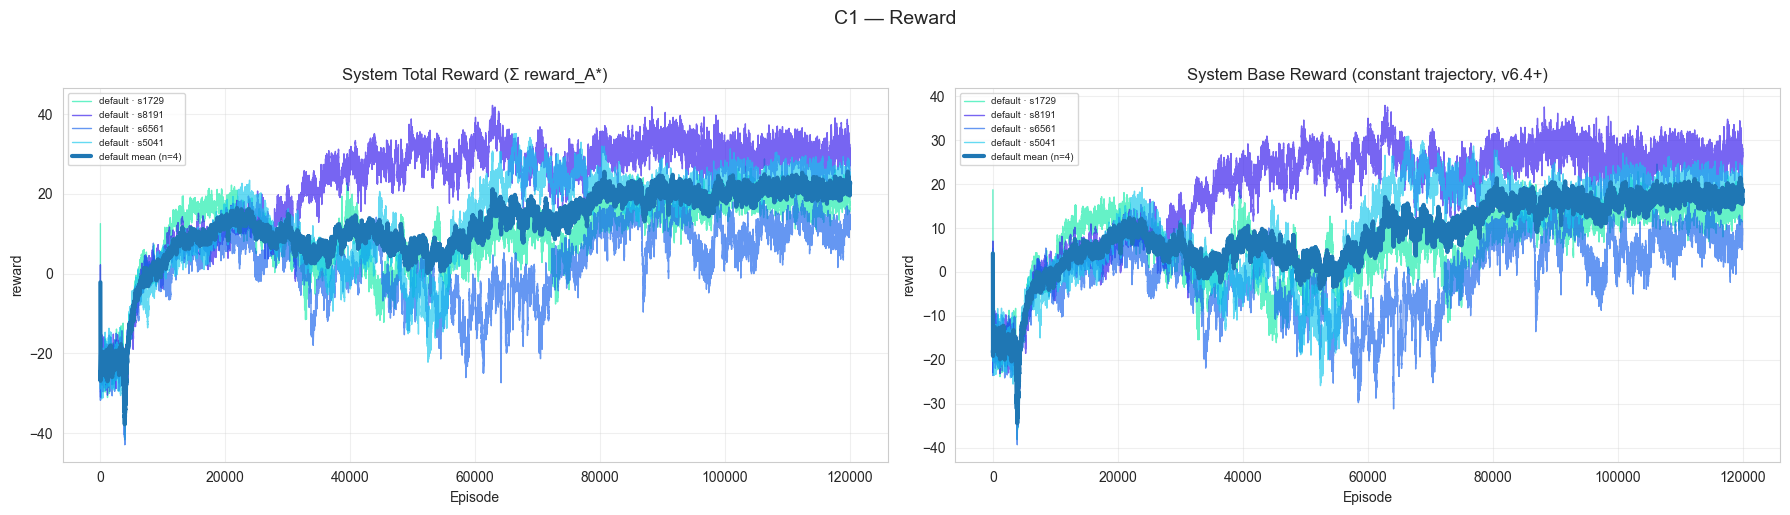

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_comparison(lambda df: _system_metric(df, 'sum', prefix='reward'),
                'System Total Reward (Σ reward_A*)', 'reward', ax=axes[0])
def _base_reward(df):
    cols = _agent_cols(df, 'reward_base')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)
plot_comparison(_base_reward, 'System Base Reward (constant trajectory, v6.4+)', 'reward', ax=axes[1])
plt.suptitle('C1 — Reward', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.2 Convergence Quality Over Training

`quality_score` is an anchor-invariant composite that the trainer writes per
episode (v8.6+). It mirrors the reward composition (compliance, costs, green
progress) but scores price *realism* against the fundamental anchor instead of
the absolute level, and values greening from the saved-carbon perspective. It
is **only used for analysis** — it never feeds back into training.

Composite (default weights):

```
Q = 0.30 · compliance + 0.25 · price_realism + 0.25 · saved_carbon
  + 0.10 · cost_efficiency − 0.10 · volatility
```

The first panel shows the composite. The second panel shows the five
individual `Q_*` components (mean across loaded runs, per episode) so the
reader can see *which* component is driving the composite.



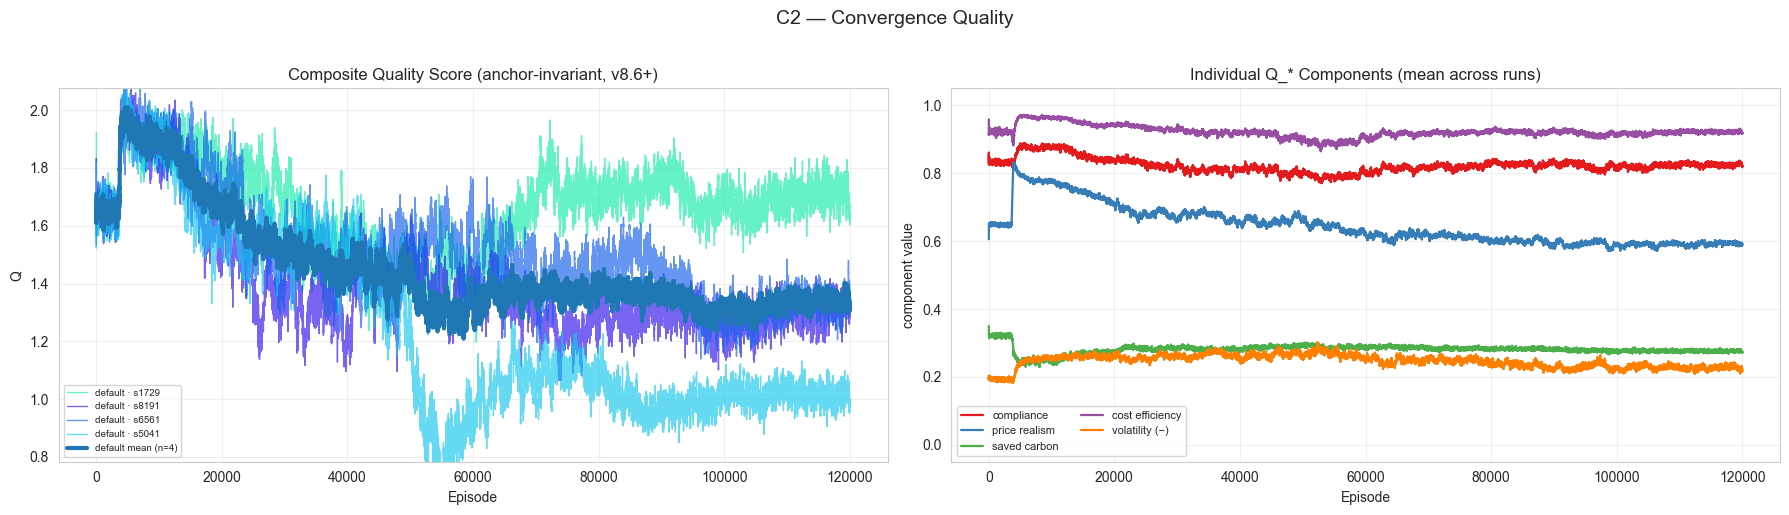

In [10]:
_Q_COMPONENTS = [
    ('Q_compliance', 'compliance'), ('Q_price_realism', 'price realism'),
    ('Q_saved_carbon', 'saved carbon'), ('Q_cost_eff', 'cost efficiency'),
    ('Q_volatility', 'volatility (−)'),
]
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Auto-tighten Y to actual data range; composite ranges in [-5, 5].
_q_frame = comparison_frame(lambda df: _system_metric(df, 'mean', col='quality_score'))
if not _q_frame.empty:
    _q_smooth = _q_frame.rolling(COMPARE_ROLL, min_periods=1).mean()
    _q_lo = float(np.nanpercentile(_q_smooth.values, 1))
    _q_hi = float(np.nanpercentile(_q_smooth.values, 99))
    _pad = max(0.1, 0.08 * (_q_hi - _q_lo))
    _q_ylim = (max(-5.0, _q_lo - _pad), min(5.0, _q_hi + _pad))
else:
    _q_ylim = (-5.0, 5.0)

plot_comparison(lambda df: _system_metric(df, 'mean', col='quality_score'),
                'Composite Quality Score (anchor-invariant, v8.6+)', 'Q', ax=axes[0], ylim=_q_ylim)

ax = axes[1]
_component_palette = sns.color_palette('Set1', n_colors=len(_Q_COMPONENTS))
plotted_any = False
for (csv_col, label), color in zip(_Q_COMPONENTS, _component_palette):
    series = [run['ep_df'].set_index('episode')[csv_col] for run in runs.values()
              if csv_col in run['ep_df'].columns and 'episode' in run['ep_df'].columns]
    if not series:
        continue
    smooth = pd.concat(series, axis=1).sort_index().rolling(COMPARE_ROLL, min_periods=1).mean().mean(axis=1)
    ax.plot(smooth.index, smooth.values, color=color, lw=1.6, label=label)
    plotted_any = True
if plotted_any:
    ax.set_xlabel('Episode'); ax.set_ylabel('component value')
    ax.set_title('Individual Q_* Components (mean across runs)')
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2, loc='best')
else:
    ax.text(0.5, 0.5, 'No Q_* component columns in logs', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Individual Q_* Components (mean across runs)')
plt.suptitle('C2 — Convergence Quality', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.3 Carbon Price Over Training

Three views of the carbon price: the **last-year** clearing price (what
ends the episode), the **all-years** mean (the average price level seen
across the whole 12-year trajectory), and the **intra-episode std**
(volatility). Comparing the first two reveals whether scarcity is
back-loaded or roughly flat across the episode.



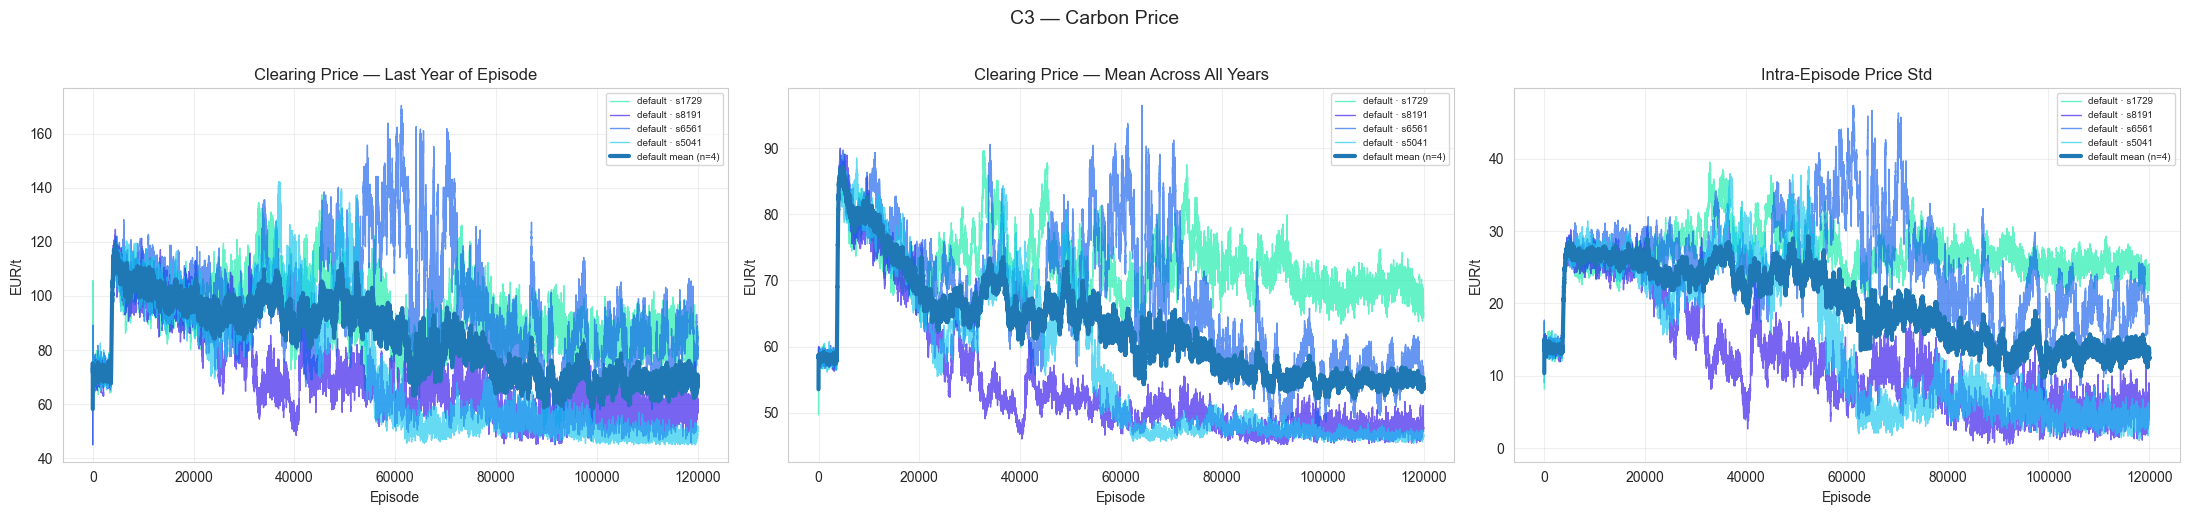

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
plot_comparison(lambda df: _system_metric(df, 'mean', col='clearing_price_last'),
                'Clearing Price — Last Year of Episode', 'EUR/t', ax=axes[0])

def _price_all_years(run):
    """Per-episode mean across all years; falls back to last-year price."""
    yr = run['yr_df']
    if 'clearing_price' in yr.columns and 'episode' in yr.columns:
        return yr.groupby('episode')['clearing_price'].mean()
    ep = run['ep_df']
    if 'clearing_price_last' in ep.columns and 'episode' in ep.columns:
        return ep.set_index('episode')['clearing_price_last']
    return pd.Series(dtype=float)
plot_comparison(_price_all_years, 'Clearing Price — Mean Across All Years', 'EUR/t', ax=axes[1], source='run')
plot_comparison(lambda df: _system_metric(df, 'mean', col='price_std'),
                'Intra-Episode Price Std', 'EUR/t', ax=axes[2])
plt.suptitle('C3 — Carbon Price', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.4 Investment Over Training

Total invested capital per episode and the system-mean green fraction.



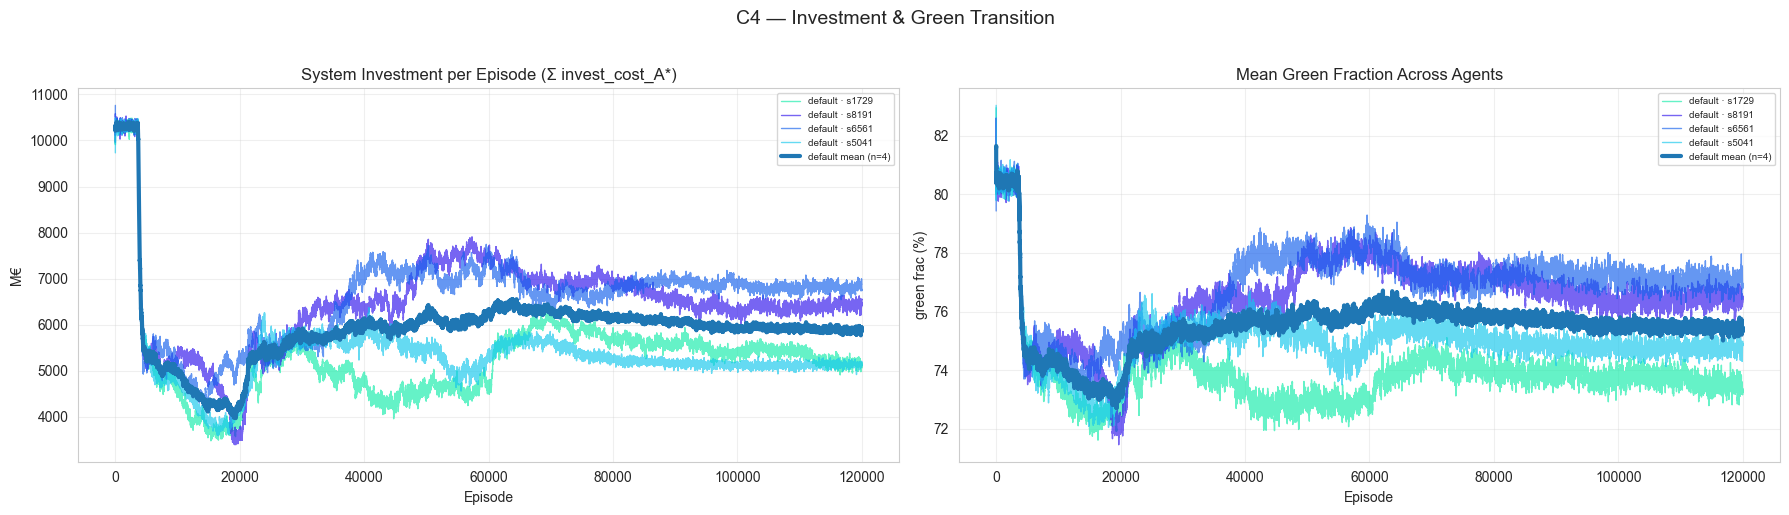

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
def _total_invest(df):
    cols = _agent_cols(df, 'invest_cost')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)
plot_comparison(_total_invest, 'System Investment per Episode (Σ invest_cost_A*)', 'M€', ax=axes[0])
plot_comparison(lambda df: _system_metric(df, 'mean', prefix='green_frac') * 100,
                'Mean Green Fraction Across Agents', 'green frac (%)', ax=axes[1])
plt.suptitle('C4 — Investment & Green Transition', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.5 Compliance Over Training

Compliance rate (agent-year): fraction of `(agent, year)` cells per
episode where shortfall ≈ 0. Same definition `scripts/train.py` prints
in its health line. The rate panel auto-zooms to the active range so
small differences across variants are visible. The companion penalty
panel uses a symlog scale because penalty totals span orders of
magnitude.



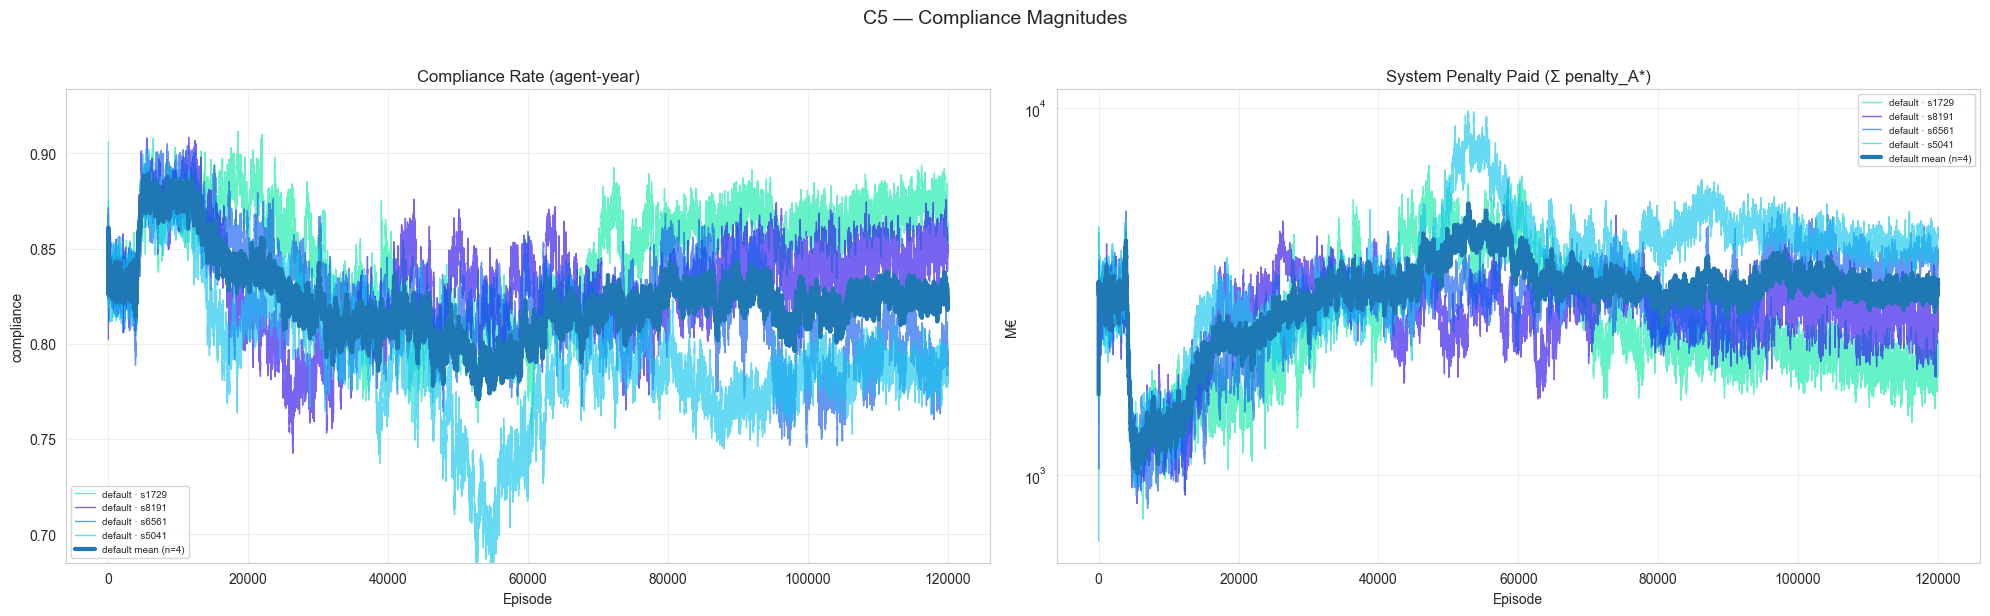

In [13]:
# Compliance helpers (used by 5.5 and 5.5a)
def _compliance_rate_from_yr(yr_df):
    """Per-episode mean compliance rate over (agent, year) cells."""
    cols = _agent_cols(yr_df, 'shortfall')
    if not cols or 'episode' not in yr_df.columns:
        return pd.Series(dtype=float)
    return (yr_df[cols] <= 1e-6).mean(axis=1).groupby(yr_df['episode']).mean()

def _bucket_total(ep_df, bucket):
    """Per-episode total UDBC count, summed across agents."""
    cols = _agent_cols(ep_df, f'udbc_{bucket}_total')
    if not cols or 'episode' not in ep_df.columns:
        return pd.Series(dtype=float)
    s = ep_df[cols].sum(axis=1); s.index = ep_df['episode']; return s

def _bucket_share(ep_df, bucket, denom_buckets):
    """Per-episode share of `bucket` in union `denom_buckets` (%)."""
    num = _bucket_total(ep_df, bucket)
    if num.empty:
        return pd.Series(dtype=float)
    denom = None
    for b in denom_buckets:
        s = _bucket_total(ep_df, b)
        denom = s if denom is None else denom.add(s, fill_value=0.0)
    return (num / denom.replace(0, np.nan)) * 100.0 if denom is not None else pd.Series(dtype=float)

# Row 1 — magnitudes (rate + penalty), drawn larger so trajectory is easy to read.
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Moderated auto-zoom: still zooms in but avoids an overly tight range.
_rate_frame = comparison_frame(_compliance_rate_from_yr, source='yr')
if not _rate_frame.empty:
    _rate_smooth = _rate_frame.rolling(COMPARE_ROLL, min_periods=1).mean()
    _r_lo = float(np.nanpercentile(_rate_smooth.values, 1))
    _r_hi = float(np.nanpercentile(_rate_smooth.values, 99))
    _center = 0.5 * (_r_lo + _r_hi)
    _target_span = max(0.12, 1.35 * max(0.0, _r_hi - _r_lo) + 0.03)
    _y0, _y1 = _center - 0.5 * _target_span, _center + 0.5 * _target_span
    if _y0 < 0.0: _y1 = min(1.02, _y1 - _y0); _y0 = 0.0
    if _y1 > 1.02: _y0 = max(0.0, _y0 - (_y1 - 1.02)); _y1 = 1.02
    _rate_ylim = (_y0, _y1)
else:
    _rate_ylim = (0.0, 1.02)

plot_comparison(_compliance_rate_from_yr, 'Compliance Rate (agent-year)',
                'compliance', ax=axes[0], ylim=_rate_ylim, source='yr')
plot_comparison(lambda df: _system_metric(df, 'sum', prefix='penalty'),
                'System Penalty Paid (Σ penalty_A*)', 'M€', ax=axes[1], log_y=True)
plt.suptitle('C5 — Compliance Magnitudes', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.5a Compliance Attribution (UDBC Buckets)

Three views of the v8.5.7 attribution buckets:

- **Total non-compliance events**: count of `(agent, year)` cells classified
  into U/D/M (i.e. the absolute number of failure-mode events per
  episode). Tells you *how often* the system is non-compliant.
- **U / D / M share**: same events split by mode, expressed as % of all
  non-compliant cells (sums to 100%). Tells you *why* — is non-compliance
  driven by under-bidding (U), inherited carry-forward debt (D), or
  both at once (M).
- **B / C share**: among compliant-but-stressed cells (the auction wasn't
  enough but the agent still closed the gap), the split between bank-
  covered (B) and secondary-buy-covered (C). Sums to 100%.



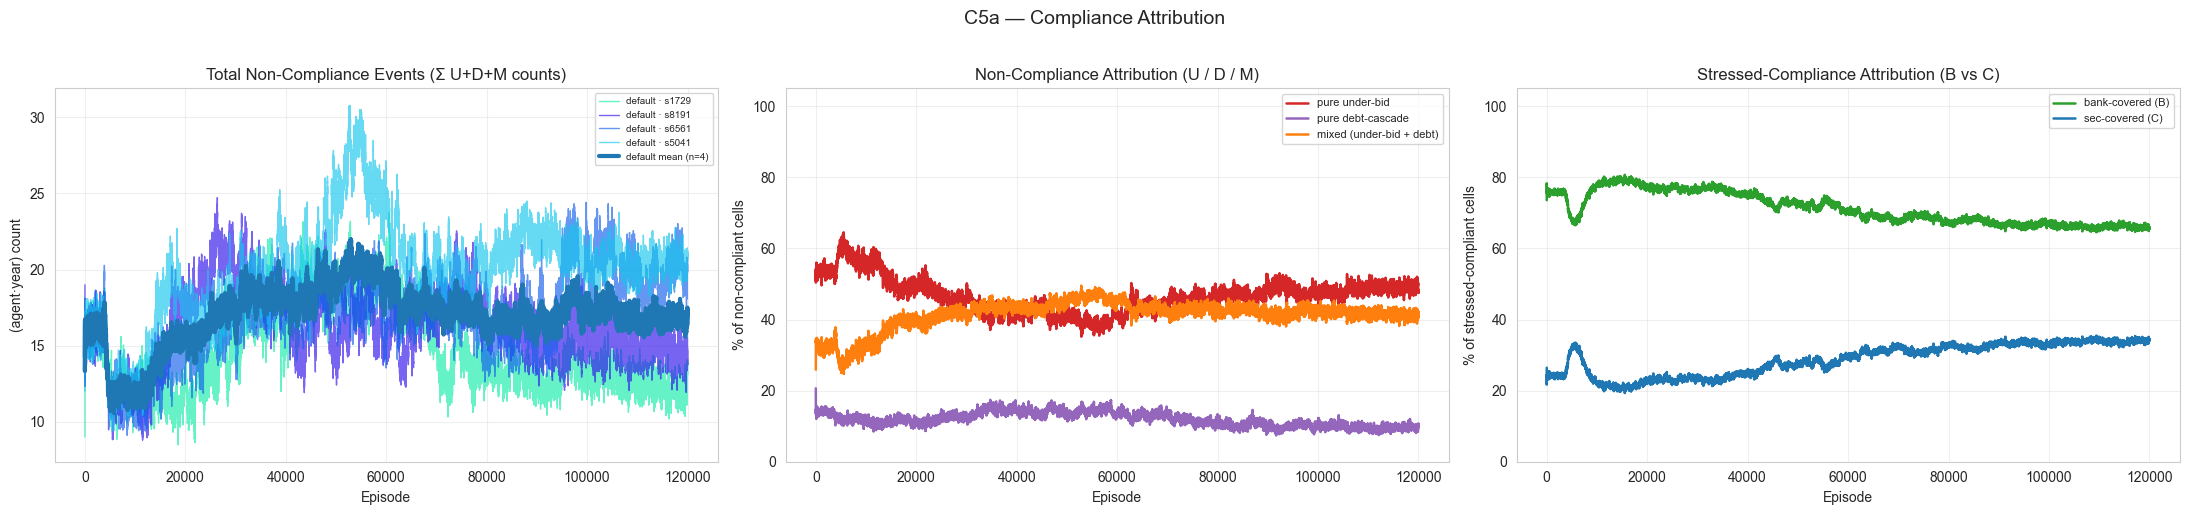

In [14]:
def _plot_avg_lines(ax, series_list, color_label_pairs, ylabel, title, ylim=None):
    """One mean-across-runs line per (color, label) pair."""
    plotted = False
    for (color, label), series in zip(color_label_pairs, series_list):
        if not series:
            continue
        smooth = pd.concat(series, axis=1).sort_index().rolling(COMPARE_ROLL, min_periods=1).mean().mean(axis=1)
        ax.plot(smooth.index, smooth.values, color=color, lw=1.8, label=label)
        plotted = True
    if plotted:
        ax.set_xlabel('Episode'); ax.set_ylabel(ylabel); ax.set_title(title)
        if ylim is not None: ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='best')
    else:
        ax.text(0.5, 0.5, 'No data in logs', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# (1) TOTAL non-compliance events per episode (Σ U+D+M counts).
def _nc_events(ep_df):
    pieces = [p for p in (_bucket_total(ep_df, b) for b in ['U', 'D', 'M']) if not p.empty]
    return sum(pieces[1:], pieces[0]) if pieces else pd.Series(dtype=float)
plot_comparison(_nc_events, 'Total Non-Compliance Events (Σ U+D+M counts)',
                '(agent·year) count', ax=axes[0])

# (2) U/D/M share among non-compliant cells.
_nc_buckets = [('U', 'pure under-bid', '#d62728'),
               ('D', 'pure debt-cascade', '#9467bd'),
               ('M', 'mixed (under-bid + debt)', '#ff7f0e')]
_nc_series = [[s for s in (_bucket_share(run['ep_df'], b, ['U', 'D', 'M']) for run in runs.values()) if not s.empty]
              for b, _, _ in _nc_buckets]
_plot_avg_lines(axes[1], _nc_series, [(c, lbl) for _, lbl, c in _nc_buckets],
                '% of non-compliant cells', 'Non-Compliance Attribution (U / D / M)', ylim=(0, 105))

# (3) B vs C among compliant-but-stressed cells.
_c_buckets = [('B', 'bank-covered (B)', '#2ca02c'), ('C', 'sec-covered (C)', '#1f77b4')]
_c_series = [[s for s in (_bucket_share(run['ep_df'], b, ['B', 'C']) for run in runs.values()) if not s.empty]
             for b, _, _ in _c_buckets]
_plot_avg_lines(axes[2], _c_series, [(c, lbl) for _, lbl, c in _c_buckets],
                '% of stressed-compliant cells', 'Stressed-Compliance Attribution (B vs C)', ylim=(0, 105))

plt.suptitle('C5a — Compliance Attribution', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.6 Secondary Market Over Training

Match rate, traded volume, and the secondary-vs-auction price ratio. The ratio is informative for spotting price-spike regimes (sec ≫ auction) where the v8.5.2/v8.5.3 `expected_remediation_rate_real` proxy kicks in.



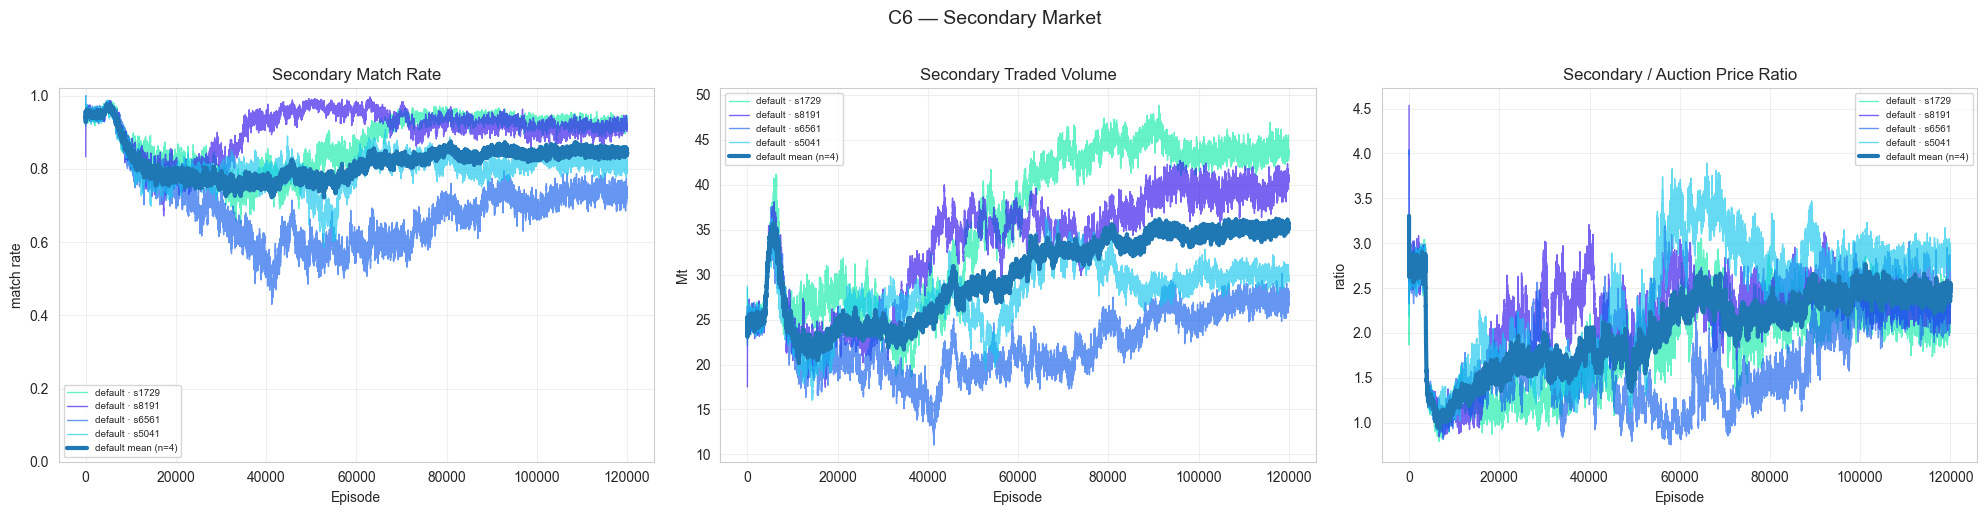

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_comparison(lambda df: _system_metric(df, 'mean', col='secondary_match_rate'),
                'Secondary Match Rate', 'match rate', ax=axes[0], ylim=(0, 1.02))
plot_comparison(lambda df: _system_metric(df, 'mean', col='secondary_volume'),
                'Secondary Traded Volume', 'Mt', ax=axes[1])
def _price_ratio(df):
    if 'secondary_price' not in df.columns or 'clearing_price_last' not in df.columns:
        return pd.Series(dtype=float)
    return df['secondary_price'] / df['clearing_price_last'].replace(0, np.nan)
plot_comparison(_price_ratio, 'Secondary / Auction Price Ratio', 'ratio', ax=axes[2])
plt.suptitle('C6 — Secondary Market', fontsize=14, y=1.02); plt.tight_layout(); plt.show()


### 5.7 Newer Diagnostics — Split-Head Losses & Year-1 Advantage

The PPO actor is split into three policy heads, each producing part of the
agent's joint action vector. They share a **single centralised critic** but
have separate actor (policy) parameters and therefore separate gradient
signals. Plotting their losses side-by-side shows whether the three heads
are learning at comparable rates or whether one is dominating / collapsing.

**The three heads:**
- **Auction head** — chooses `(bid_price, qty_mult)`, the agent's sealed
  bid into the uniform-price auction. Logged as `actor_loss_A*` /
  `critic_loss_A*` (the "main" actor/critic losses). When
  `ppo.split_invest_head=true` (v8.5+) the invest action is split off, so
  these columns track *only* the auction sub-action.
- **Invest sub-head** — chooses
  `(invest_frac, tech_logit_onshore, tech_logit_offshore, tech_logit_solar)`,
  the green-investment decision. Split out so its slow, episode-scale
  reward signal doesn't pollute the auction-head gradient. Logged as
  `actor_loss_invest_A*` / `critic_loss_invest_A*`.
- **Secondary-market head** — chooses `(sec_price_abs, sec_qty)` in
  Phase 2 of each year. Logged as `actor_loss_secondary_A*`. The
  "secondary critic" column is **aliased to the joint centralised critic**
  loss (the secondary head doesn't have a dedicated critic), so panels
  (1,2), (2,2), (3,2) all mirror the same critic signal.

**How to read each loss panel:**
- The PPO actor loss is the negative clipped surrogate, so values close to
  zero (or slightly negative) mean the head's policy is barely changing.
  Large-magnitude swings in either direction indicate active learning —
  expected during the early epochs and during entropy-decay transitions.
- The critic (value-net) loss is mean-squared TD error. It should
  decrease roughly monotonically once the warmup phase ends.

**The advantage panels (right column):**
- *Year-1 mean advantage (cohort)* — average across all learning agents
  of the pre-normalisation GAE advantage on the *first year* of each
  episode. The trainer floors this at −1.0 (v8.4.1) to stop early-training
  year-1 transitions from blowing out gradients via the year-1 stochastic
  shock; the diagnostic exposes the **un-floored** raw value so you can
  see how often the floor is biting. A persistent value far below 0
  means year-1 is being penalised heavily.
- *Year-1 mean advantage (A1 only)* — same statistic, but for agent A1
  only. Kept as a legacy reference because earlier `train.py` versions
  only logged the A1 column.



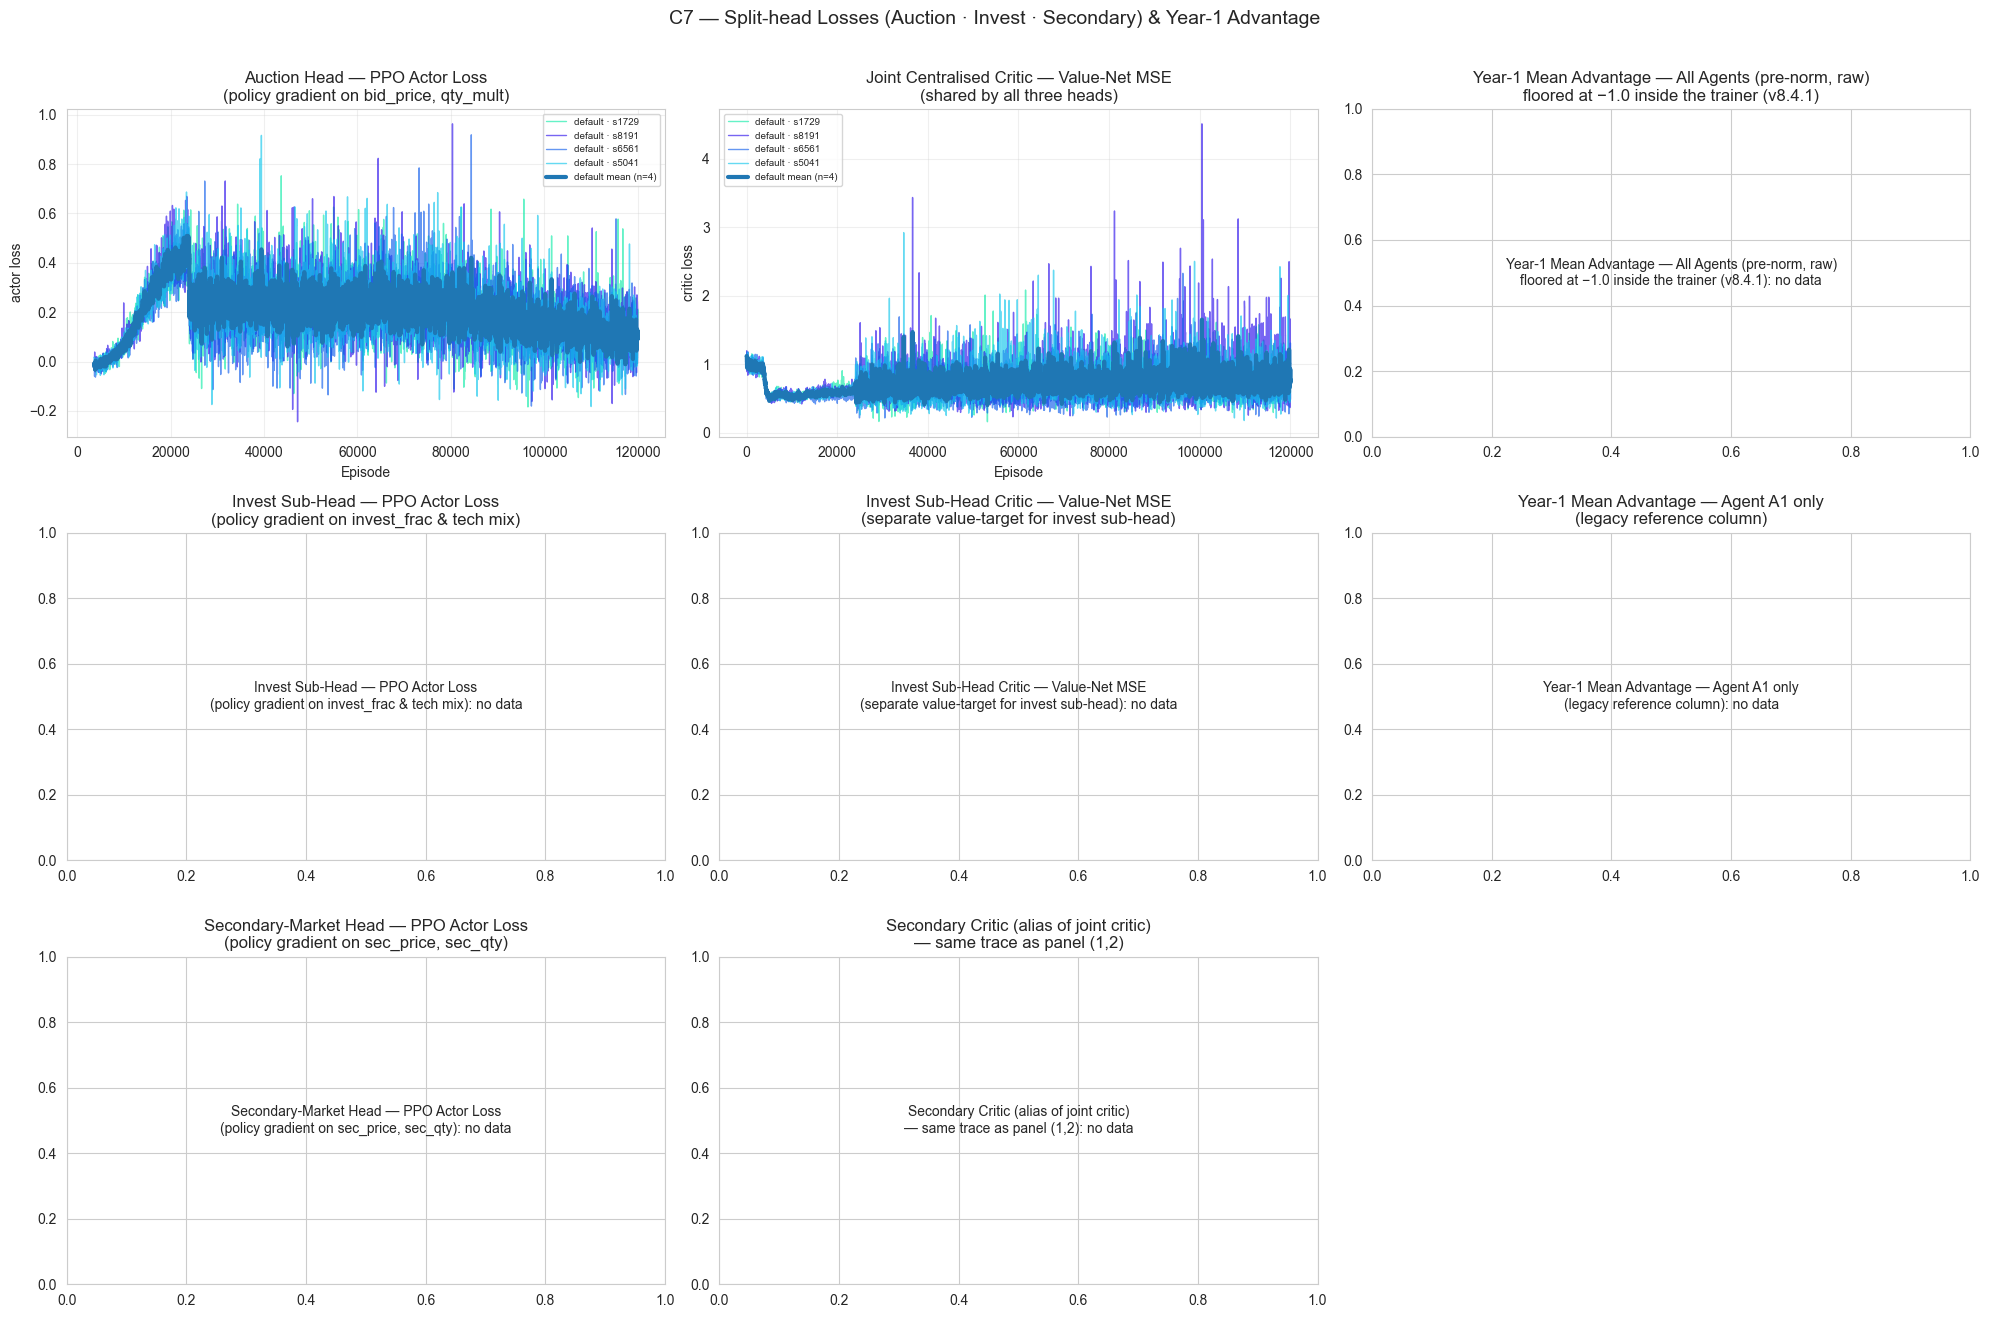

In [16]:
# All three actor heads share one centralised critic; "secondary critic" is aliased to it.
fig, axes = plt.subplots(3, 3, figsize=(20, 13))

def _mean_loss(df, prefix):
    cols = _agent_cols(df, prefix)
    # Replace exact-zero rows (warmup/fallback) with NaN so the mean reflects real training steps.
    return df[cols].replace(0, np.nan).mean(axis=1) if cols else pd.Series(dtype=float)

def _adv_yr1_all(df):
    cols = _agent_cols(df, 'adv_yr1_mean')
    if cols:
        return df[cols].replace(0, np.nan).mean(axis=1)
    return df['adv_yr1_mean_A1'] if 'adv_yr1_mean_A1' in df.columns else pd.Series(dtype=float)

# Row 1 — AUCTION head: (bid_price, qty_mult). "Main" actor/critic when split_invest_head=True.
plot_comparison(lambda df: _mean_loss(df, 'actor_loss'),
                'Auction Head — PPO Actor Loss\n(policy gradient on bid_price, qty_mult)',
                'actor loss', ax=axes[0, 0])
plot_comparison(lambda df: _mean_loss(df, 'critic_loss'),
                'Joint Centralised Critic — Value-Net MSE\n(shared by all three heads)',
                'critic loss', ax=axes[0, 1])
plot_comparison(_adv_yr1_all,
                'Year-1 Mean Advantage — All Agents (pre-norm, raw)\nfloored at −1.0 inside the trainer (v8.4.1)',
                'advantage', ax=axes[0, 2])

# Row 2 — INVEST sub-head: (invest_frac, tech logits).
plot_comparison(lambda df: _mean_loss(df, 'actor_loss_invest'),
                'Invest Sub-Head — PPO Actor Loss\n(policy gradient on invest_frac & tech mix)',
                'actor loss', ax=axes[1, 0])
plot_comparison(lambda df: _mean_loss(df, 'critic_loss_invest'),
                'Invest Sub-Head Critic — Value-Net MSE\n(separate value-target for invest sub-head)',
                'critic loss', ax=axes[1, 1])
plot_comparison(lambda df: df['adv_yr1_mean_A1'] if 'adv_yr1_mean_A1' in df.columns else pd.Series(dtype=float),
                'Year-1 Mean Advantage — Agent A1 only\n(legacy reference column)',
                'advantage', ax=axes[1, 2])

# Row 3 — SECONDARY head: (sec_price_abs, sec_qty) in Phase 2.
plot_comparison(lambda df: _mean_loss(df, 'actor_loss_secondary'),
                'Secondary-Market Head — PPO Actor Loss\n(policy gradient on sec_price, sec_qty)',
                'actor loss', ax=axes[2, 0])
plot_comparison(lambda df: _mean_loss(df, 'critic_loss_secondary'),
                'Secondary Critic (alias of joint critic)\n— same trace as panel (1,2)',
                'critic loss', ax=axes[2, 1])
axes[2, 2].axis('off')

plt.suptitle('C7 — Split-head Losses (Auction · Invest · Secondary) & Year-1 Advantage',
             fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 5.8 Per-Variant Summary Table (Converged Window)

All metrics averaged over the last `ANALYSIS_TAIL_FRAC` of episodes — a single row per variant for thesis tables. Compliance here is the proper agent-year rate (matches §5.5).



In [17]:
# Converged-window summary: mean over the LAST `ANALYSIS_TAIL_EPISODES` episodes.
def _tail(df, n=ANALYSIS_TAIL_EPISODES):
    return df if df.empty else df.tail(min(n, len(df)))

summary_rows = []
for (variant, seed), run in runs.items():
    ep, yr = run['ep_df'], run['yr_df']
    ep_tail = _tail(ep)
    yr_tail = (yr[yr['episode'].isin(ep_tail['episode'].unique())]
               if 'episode' in yr.columns else _tail(yr))

    rew_cols = _agent_cols(ep_tail, 'reward')
    inv_cols = _agent_cols(ep_tail, 'invest_cost')
    gf_cols = _agent_cols(ep_tail, 'green_frac')
    pen_cols = _agent_cols(ep_tail, 'penalty')
    coll_cols = _agent_cols(yr_tail, 'collateral_cost')
    sf_cols_yr = _agent_cols(yr_tail, 'shortfall')

    compliance_rate = float((yr_tail[sf_cols_yr] <= 1e-6).mean(axis=1).mean()) if sf_cols_yr else float('nan')
    if 'clearing_price' in yr_tail.columns:
        price_all_years = float(yr_tail['clearing_price'].mean())
    elif 'clearing_price_last' in ep_tail.columns:
        price_all_years = float(ep_tail['clearing_price_last'].mean())
    else:
        price_all_years = float('nan')

    summary_rows.append({
        'variant': variant, 'seed': seed,
        'system_reward': float(ep_tail[rew_cols].sum(axis=1).mean()) if rew_cols else np.nan,
        'quality_score': float(ep_tail['quality_score'].dropna().mean()) if 'quality_score' in ep_tail.columns else np.nan,
        'price_final_year': float(ep_tail['clearing_price_last'].mean()) if 'clearing_price_last' in ep_tail.columns else np.nan,
        'price_all_years': price_all_years,
        'price_std': float(ep_tail['clearing_price_last'].std()) if 'clearing_price_last' in ep_tail.columns else np.nan,
        'sec_match_rate': float(ep_tail['secondary_match_rate'].mean()) if 'secondary_match_rate' in ep_tail.columns else np.nan,
        'compliance_rate': compliance_rate,
        'system_penalty': float(ep_tail[pen_cols].sum(axis=1).mean()) if pen_cols else np.nan,
        'system_invest': float(ep_tail[inv_cols].sum(axis=1).mean()) if inv_cols else np.nan,
        'green_frac_mean': float(ep_tail[gf_cols].mean(axis=1).mean()) if gf_cols else np.nan,
        'collateral_year_mean': float(yr_tail[coll_cols].sum(axis=1).mean()) if coll_cols else np.nan,
        'n_episodes': int(len(ep)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_col_order = ['variant', 'seed', 'system_reward', 'quality_score',
                     'price_final_year', 'price_all_years', 'price_std', 'sec_match_rate',
                     'compliance_rate', 'system_penalty', 'system_invest', 'green_frac_mean',
                     'collateral_year_mean', 'n_episodes']
summary_df = summary_df[[c for c in summary_col_order if c in summary_df.columns]]

agg_funcs = {
    'system_reward': ['mean', 'std'], 'quality_score': ['mean', 'std'],
    'price_final_year': ['mean', 'std'], 'price_all_years': ['mean', 'std'],
    'compliance_rate': ['mean', 'std'], 'system_invest': ['mean', 'std'],
    'green_frac_mean': ['mean', 'std'], 'collateral_year_mean': ['mean'],
    'sec_match_rate': ['mean'], 'system_penalty': ['mean'], 'seed': 'count',
}
by_variant = summary_df.groupby('variant').agg(agg_funcs)
by_variant.columns = ['_'.join([c for c in col if c]) for col in by_variant.columns]
by_variant = by_variant.rename(columns={'seed_count': 'n_seeds'}).round(3)

print(f'Per-(variant, seed) summary — last {ANALYSIS_TAIL_EPISODES} episodes:')
display(summary_df.round(3))
print('\nAggregated by variant (mean ± std across seeds):')
by_variant


Per-(variant, seed) summary — last 200 episodes:


,variant,seed,system_reward,quality_score,price_final_year,price_all_years,price_std,sec_match_rate,compliance_rate,system_penalty,system_invest,green_frac_mean,collateral_year_mean,n_episodes
0,default,1729,20.853,1.665,80.921,66.002,30.251,0.929,0.869,1965.127,5105.939,0.734,30.956,120000
1,default,8191,29.125,1.325,60.960,48.761,35.346,0.922,0.850,2750.064,6427.856,0.764,12.126,120000
2,default,6561,12.440,1.326,81.258,55.902,29.886,0.733,0.793,3929.627,6847.964,0.770,21.462,120000
3,default,5041,25.155,1.002,49.447,46.675,15.955,0.805,0.786,4297.632,5132.392,0.747,18.561,120000



Aggregated by variant (mean ± std across seeds):


,system_reward_mean,system_reward_std,quality_score_mean,quality_score_std,price_final_year_mean,price_final_year_std,price_all_years_mean,price_all_years_std,compliance_rate_mean,compliance_rate_std,system_invest_mean,system_invest_std,green_frac_mean_mean,green_frac_mean_std,collateral_year_mean_mean,sec_match_rate_mean,system_penalty_mean,n_seeds
variant,,,,,,,,,,,,,,,,,,
default,21.893,7.15,1.329,0.27,68.146,15.667,54.335,8.724,0.825,0.041,5878.538,893.529,0.754,0.017,20.776,0.847,3235.613,4


### 5.9 Cross-variant credit stress & auction concentration

Compares the v8.6.1 expanded-logging columns across sweep variants.
Backward-compatible: each panel silently no-ops when the underlying logs
lack the columns (variants trained before 8.6.1).

* **Auction concentration** — converged-window mean `auction_hhi` and
  `auction_max_agent_share` per variant. Higher HHI ⇒ more concentrated
  allocation among a few agents.
* **Auction supply/demand** — converged-window mean `auction_unsold` per
  variant; flag variants where the primary auction routinely under-clears.
* **System credit stress** — converged-window mean of system-aggregate
  `peak_loan_outstanding` and `peak_carry_forward`. Variants that score
  similarly on `quality_score` but differ here are propping up compliance
  with debt rather than genuine market participation.


Per-variant converged-window means (± cross-seed std):


seed            auction_hhi          auction_max_agent_share         auction_unsold         auction_failed      peak_loan_outstanding      peak_carry_forward          \
           mean        std        mean      std                    mean     std           mean     std           mean  std                  mean  std               mean     std   
variant                                                                                                                                                                            
default  5380.5  2753.2528   1786.6259  73.6525                  0.2704  0.0054         0.4736  0.7275            0.0  0.0                   0.0  0.0             5.8947  1.3423   

        final_treasury_reserve            
                          mean       std  
variant                                   
default              7448.0868  566.3239

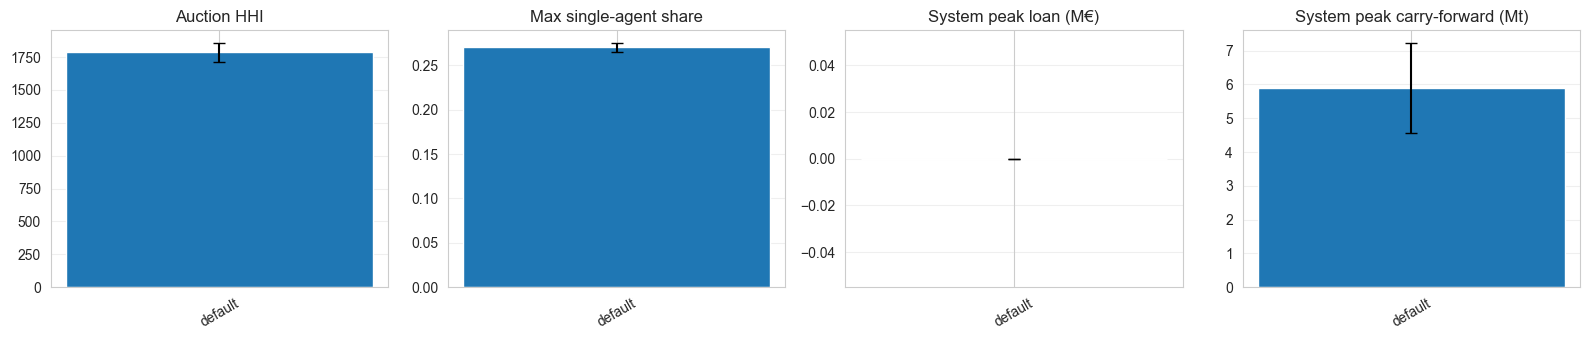

In [18]:
# 5.9 — Cross-variant comparison on v8.6.1 columns. Falls back gracefully
# on pre-8.6.1 runs.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _converged_yr_mean(yr_df, col, agg="mean"):
    if col not in yr_df.columns or yr_df.empty:
        return np.nan
    if "episode" in yr_df.columns:
        cut = max(0, int(yr_df["episode"].max()) - ANALYSIS_TAIL_EPISODES + 1)
        tail = yr_df[yr_df["episode"] >= cut]
    else:
        tail = yr_df
    if tail.empty:
        return np.nan
    return float(tail[col].mean() if agg == "mean" else tail[col].sum())

def _converged_ep_system_peak(ep_df, stub):
    cols = [c for c in ep_df.columns if c.startswith(stub + "_A")]
    if not cols or ep_df.empty:
        return np.nan
    if "episode" in ep_df.columns:
        cut = max(0, int(ep_df["episode"].max()) - ANALYSIS_TAIL_EPISODES + 1)
        tail = ep_df[ep_df["episode"] >= cut]
    else:
        tail = ep_df
    if tail.empty:
        return np.nan
    return float(tail[cols].sum(axis=1).mean())

rows = []
for (variant, seed), run in runs.items():
    ep = run.get("ep_df", pd.DataFrame())
    yr = run.get("yr_df", pd.DataFrame())
    rows.append({
        "variant": variant, "seed": seed,
        "auction_hhi":             _converged_yr_mean(yr, "auction_hhi"),
        "auction_max_agent_share": _converged_yr_mean(yr, "auction_max_agent_share"),
        "auction_unsold":          _converged_yr_mean(yr, "auction_unsold"),
        "auction_failed":          _converged_yr_mean(yr, "auction_failed"),
        "peak_loan_outstanding":   _converged_ep_system_peak(ep, "peak_loan_outstanding"),
        "peak_carry_forward":      _converged_ep_system_peak(ep, "peak_carry_forward"),
        "final_treasury_reserve":  _converged_ep_system_peak(ep, "final_treasury_reserve"),
    })
sweep59_df = pd.DataFrame(rows)

if sweep59_df.empty or sweep59_df.drop(columns=["variant", "seed"]).isna().all().all():
    print("[5.9] v8.6.1 expanded-logging columns missing — runs likely predate 8.6.1.")
else:
    summary = sweep59_df.groupby("variant").agg(["mean", "std"])
    print("Per-variant converged-window means (± cross-seed std):")
    display(summary.round(4))

    # Plot variant-level bars for the four headline metrics. Each metric is
    # only drawn when at least one variant has a finite value.
    metrics = [
        ("auction_hhi",             "Auction HHI"),
        ("auction_max_agent_share", "Max single-agent share"),
        ("peak_loan_outstanding",   "System peak loan (M€)"),
        ("peak_carry_forward",      "System peak carry-forward (Mt)"),
    ]
    finite = [m for m, _ in metrics if sweep59_df[m].notna().any()]
    if finite:
        n = len(finite); fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 3.5))
        if n == 1: axes = [axes]
        for ax, m in zip(axes, finite):
            label = dict(metrics)[m]
            ag = sweep59_df.groupby("variant")[m].agg(["mean", "std"]).dropna(subset=["mean"])
            colors = [VARIANT_COLOR.get(v, "tab:blue") for v in ag.index]
            ax.bar(ag.index, ag["mean"], yerr=ag["std"].fillna(0.0),
                   color=colors, capsize=4)
            ax.set_title(label); ax.tick_params(axis="x", rotation=30)
            ax.grid(alpha=0.3, axis="y")
        plt.tight_layout(); plt.show()


---
## 6. Deep Dive — Pick One Run

Set `PICK_VARIANT` and `PICK_SEED` to the run you want to investigate in
detail. Re-run the cells from here to refresh the deep-dive plots
without recomputing the comparison sections above.


In [ ]:
# Choose which (variant, seed) to deep-dive on. Defaults to the first loaded run; override below if needed.
PICK_VARIANT = next(iter(runs))[0]
PICK_SEED    = next(iter(runs))[1]
#PICK_VARIANT = 'unsold_to_msr_on'
PICK_SEED    = 1729 #904

_run = runs[(PICK_VARIANT, PICK_SEED)]
ep_df = _run['ep_df'].copy()
yr_df = _run['yr_df']  # don't .copy(); year-level df is large

# Downcast numerics in-place to reduce RAM.
for c in yr_df.select_dtypes(include=['float64', 'int64']).columns:
    yr_df[c] = pd.to_numeric(yr_df[c], downcast='float' if pd.api.types.is_float_dtype(yr_df[c]) else 'integer')

config = _run['config']
n_agents = int(config.get('companies', {}).get('n_agents', 8))

LAST_N = min(ANALYSIS_TAIL_EPISODES, max(1, len(ep_df) // 4))
last_episodes = ep_df['episode'].unique()[-LAST_N:]
recent_ep = ep_df[ep_df['episode'].isin(last_episodes)].copy()
recent_yr = yr_df[yr_df['episode'].isin(last_episodes)].copy()
ROLL = 50
n_years_per_ep = yr_df.groupby('episode')['year'].count().mode().iloc[0]

agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
agent_labels = []
for arch in _base_archetypes:
    for _ in range(n_agents // 4):
        agent_labels.append(f'A{len(agent_labels)+1} ({arch})')
while len(agent_labels) < n_agents:
    agent_labels.append(f'A{len(agent_labels)+1}')

print(f'Deep-diving on: variant={PICK_VARIANT}, seed={PICK_SEED}')
print(f'  {len(ep_df)} episodes, {len(yr_df)} year-rows, {n_years_per_ep} years/episode, {n_agents} learning agents')
print(f'  Converged window: last {LAST_N} episodes')


Deep-diving on: variant=default, seed=1729
  120000 episodes, 1440000 year-rows, 12 years/episode, 8 learning agents
  Converged window: last 200 episodes


---
# Part I — Diagnostic Deep Dive (D)

> *Is the simulation behaving correctly?*
>
> Reordered vs. the original notebook: **D5 (stochastic shocks) is last**, and the dedicated green-investing (D7) and collateral (D9 / D9b) sections are removed. Collateral is folded into the reward-decomposition panel in §A5.


### D1. Training Convergence

Check that neural networks are learning stably:
- Losses decreasing
- Entropy decay triggered at the right time
- Rewards stabilizing

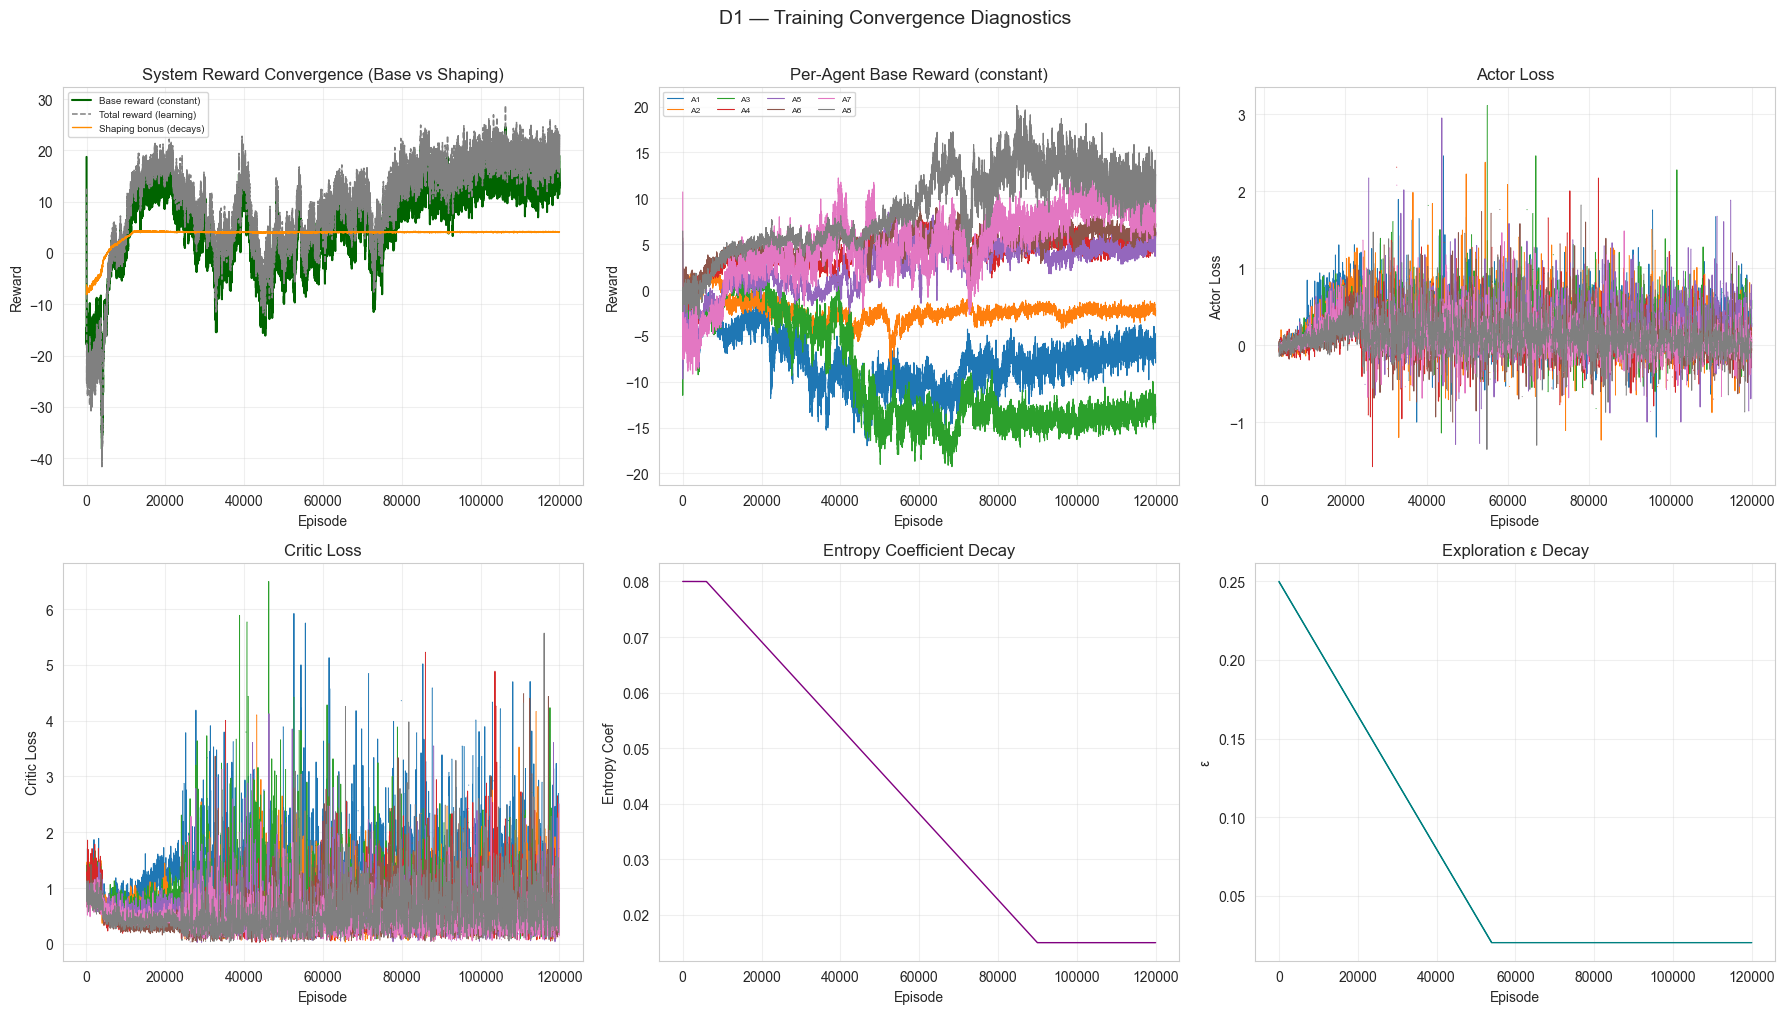

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
reward_cols_total = [f'reward_A{i+1}' for i in range(n_agents) if f'reward_A{i+1}' in ep_df.columns]
reward_cols_base = [f'reward_base_A{i+1}' for i in range(n_agents) if f'reward_base_A{i+1}' in ep_df.columns]
reward_cols_shaping = [f'reward_shaping_A{i+1}' for i in range(n_agents) if f'reward_shaping_A{i+1}' in ep_df.columns]

# 1 — System reward (base vs shaping when available)
ax = axes[0, 0]
if reward_cols_total:
    total_roll = ep_df[reward_cols_total].sum(axis=1).rolling(ROLL, min_periods=1).mean()
    if reward_cols_base:
        base_roll = ep_df[reward_cols_base].sum(axis=1).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], base_roll, color='darkgreen', lw=1.5, label='Base reward (constant)')
        ax.plot(ep_df['episode'], total_roll, color='gray', lw=1.1, ls='--', label='Total reward (learning)')
        if reward_cols_shaping:
            shape_roll = ep_df[reward_cols_shaping].sum(axis=1).rolling(ROLL, min_periods=1).mean()
            ax.plot(ep_df['episode'], shape_roll, color='darkorange', lw=1.0, label='Shaping bonus (decays)')
        ax.legend(fontsize=7); ax.set_title('System Reward Convergence (Base vs Shaping)')
    else:
        ax.plot(ep_df['episode'], total_roll, color='darkgreen', lw=1.2)
        ax.set_title('System Reward Convergence (Total only)')
else:
    ax.text(0.5, 0.5, 'Reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 2 — Per-agent reward
ax = axes[0, 1]
for i in range(n_agents):
    col = f'reward_base_A{i+1}' if reward_cols_base else f'reward_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Base Reward (constant)' if reward_cols_base else 'Per-Agent Reward (total)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Actor loss / 4 — Critic loss
for ax, prefix, title in [(axes[0, 2], 'actor_loss', 'Actor Loss'),
                          (axes[1, 0], 'critic_loss', 'Critic Loss')]:
    for i in range(n_agents):
        col = f'{prefix}_A{i+1}'
        if col in ep_df.columns:
            ax.plot(ep_df['episode'], ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean(),
                    color=agent_colors[i], lw=0.7)
    ax.set_xlabel('Episode'); ax.set_ylabel(title); ax.set_title(title); ax.grid(True, alpha=0.3)

# 5 — Entropy / 6 — Epsilon
axes[1, 1].plot(ep_df['episode'], ep_df['entropy_coef'], color='purple', lw=1)
axes[1, 1].set(xlabel='Episode', ylabel='Entropy Coef', title='Entropy Coefficient Decay'); axes[1, 1].grid(True, alpha=0.3)
axes[1, 2].plot(ep_df['episode'], ep_df['epsilon'], color='teal', lw=1)
axes[1, 2].set(xlabel='Episode', ylabel='ε', title='Exploration ε Decay'); axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('D1 — Training Convergence Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D2. Carbon Price & Cap Schedule

The clearing price should broadly reflect real EU ETS dynamics:
- Phase 4 prices in the €50–100 range
- Prices rising as the cap tightens under the LRF
- TNAC declining over time as MSR absorbs surplus

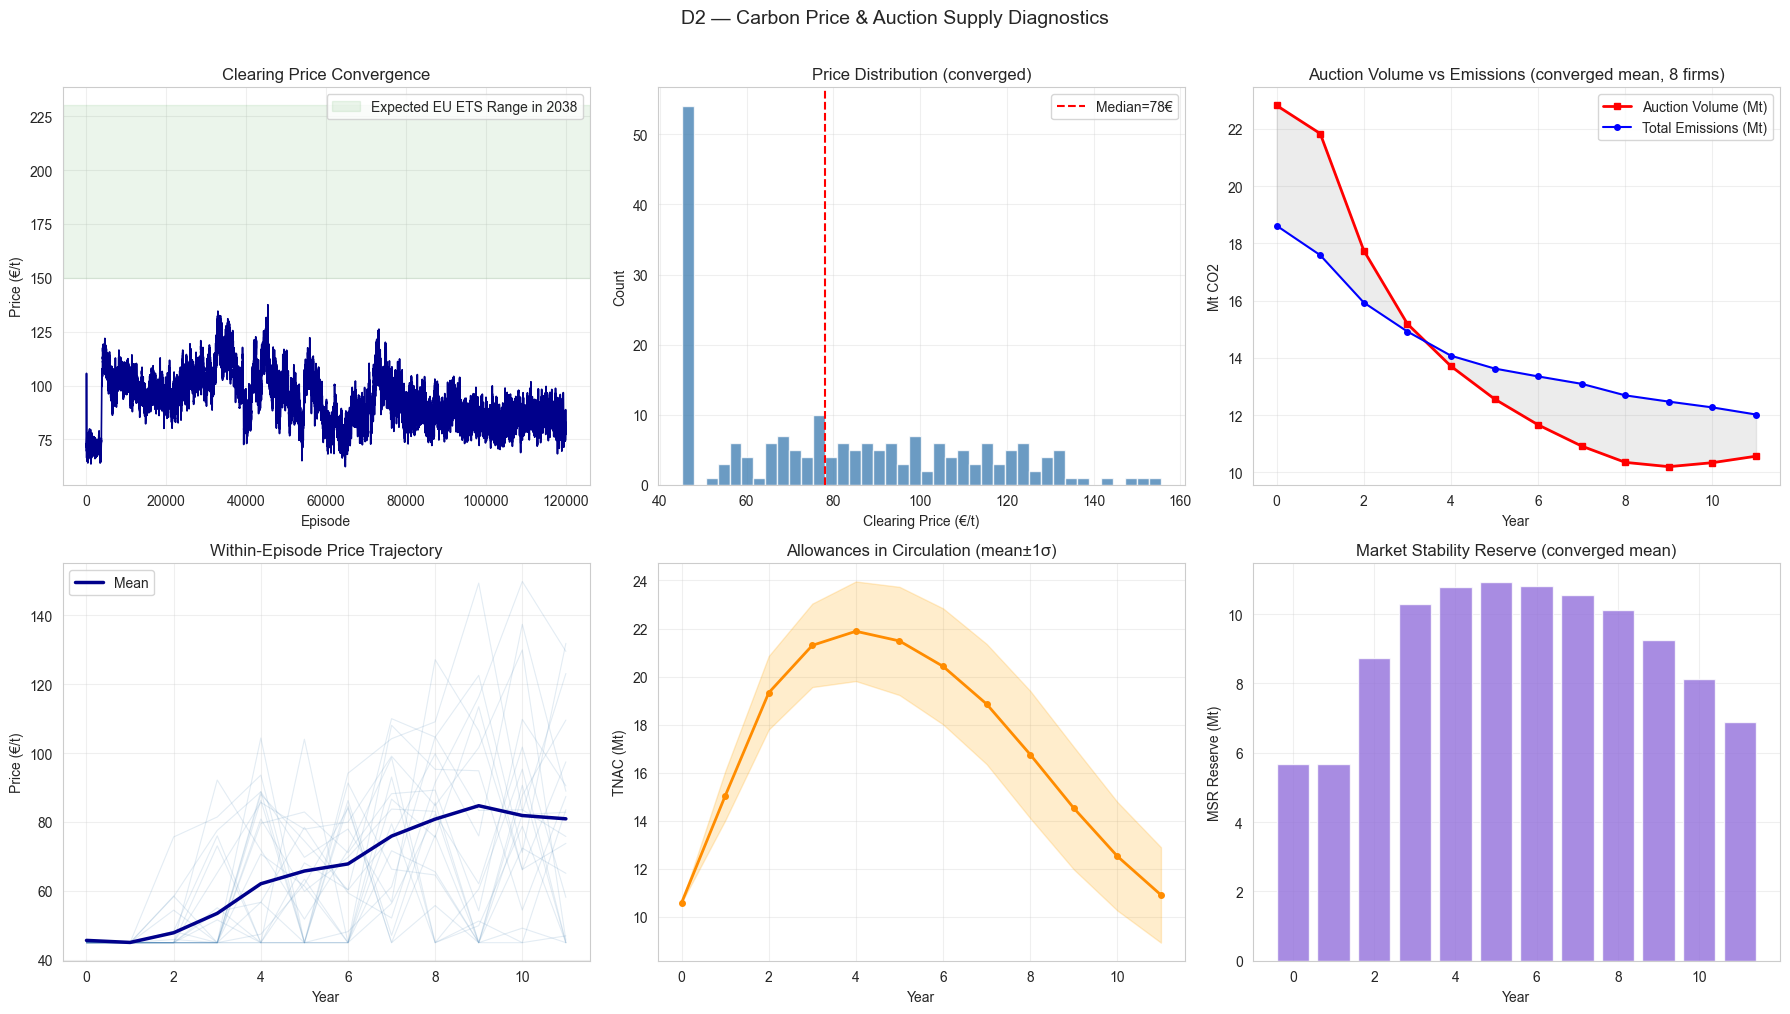

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Clearing price over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(), color='darkblue', lw=1.2)
ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
ax.set(xlabel='Episode', ylabel='Price (€/t)', title='Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Price distribution (converged)
ax = axes[0, 1]
prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
ax.set(xlabel='Clearing Price (€/t)', ylabel='Count', title='Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Auctioned volume vs total emissions
ax = axes[0, 2]
auction_by_yr = recent_yr.groupby('year')['auction_volume'].mean()
emis_cols = sorted([c for c in recent_yr.columns if c.startswith('emissions_A')], key=lambda c: int(c.split('_A')[1]))
emis_by_yr = recent_yr[emis_cols].sum(axis=1).groupby(recent_yr['year']).mean()
ax.plot(auction_by_yr.index, auction_by_yr.values, 'r-s', ms=5, label='Auction Volume (Mt)', lw=2)
ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions (Mt)', lw=1.5)
ax.fill_between(auction_by_yr.index, auction_by_yr.values, emis_by_yr.values, alpha=0.15, color='gray')
ax.set(xlabel='Year', ylabel='Mt CO2', title=f'Auction Volume vs Emissions (converged mean, {len(emis_cols)} firms)')
ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Within-episode price trajectory
ax = axes[1, 0]
for ep in sorted(recent_yr['episode'].unique()[-20:]):
    ep_data = recent_yr[recent_yr['episode'] == ep]
    ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
mean_price_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(mean_price_yr.index, mean_price_yr.values, 'darkblue', lw=2.5, label='Mean')
ax.set(xlabel='Year', ylabel='Price (€/t)', title='Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — TNAC over years
ax = axes[1, 1]
tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std'])
ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
ax.fill_between(tnac_yr.index, tnac_yr['mean'] - tnac_yr['std'].fillna(0.0),
                tnac_yr['mean'] + tnac_yr['std'].fillna(0.0), alpha=0.2, color='orange')
ax.set(xlabel='Year', ylabel='TNAC (Mt)', title='Allowances in Circulation (mean±1σ)'); ax.grid(True, alpha=0.3)

# 6 — MSR reserve
ax = axes[1, 2]
msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
ax.set(xlabel='Year', ylabel='MSR Reserve (Mt)', title='Market Stability Reserve (converged mean)'); ax.grid(True, alpha=0.3)

plt.suptitle('D2 — Carbon Price & Auction Supply Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D3. Auction Mechanics

Sanity checks for the uniform-price auction:
- Allocations should sum to roughly the auctioned volume
- Bid prices should bracket the clearing price
- No persistent auction failures

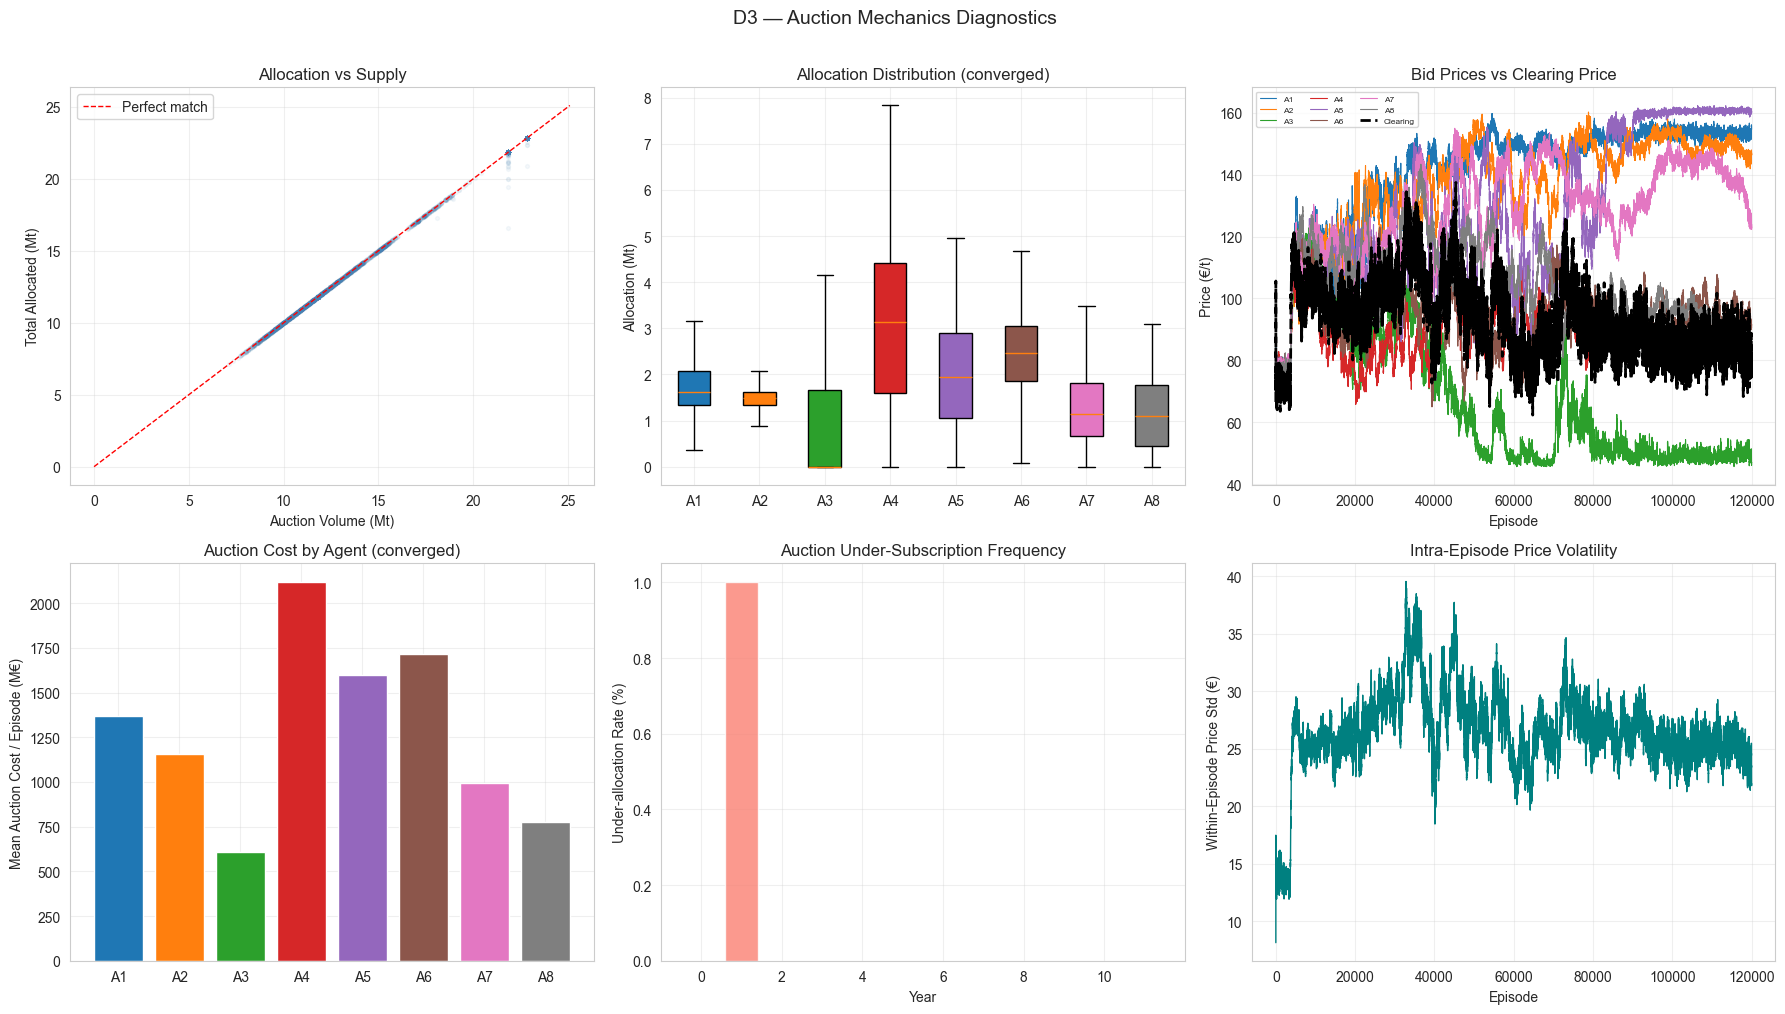

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Total allocation vs auction volume
ax = axes[0, 0]
alloc_cols = [f'alloc_A{i+1}' for i in range(n_agents)]
alloc_total = recent_yr[alloc_cols].sum(axis=1)
ax.scatter(recent_yr['auction_volume'], alloc_total, alpha=0.05, s=8, color='steelblue')
lims = [0, max(recent_yr['auction_volume'].max(), alloc_total.max()) * 1.1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect match')
ax.set(xlabel='Auction Volume (Mt)', ylabel='Total Allocated (Mt)', title='Allocation vs Supply'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Per-agent allocation distribution
ax = axes[0, 1]
bp = ax.boxplot([recent_yr[f'alloc_A{i+1}'].values for i in range(n_agents)],
                tick_labels=[f'A{i+1}' for i in range(n_agents)], patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']): patch.set_facecolor(agent_colors[i])
ax.set(ylabel='Allocation (Mt)', title='Allocation Distribution (converged)'); ax.grid(True, alpha=0.3)

# 3 — Bid price vs clearing price
ax = axes[0, 2]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(), 'k--', lw=2, label='Clearing')
ax.set(xlabel='Episode', ylabel='Price (€/t)', title='Bid Prices vs Clearing Price')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Auction cost per agent (converged)
ax = axes[1, 0]
acost_means = [recent_yr.groupby('episode')[f'auction_cost_A{i+1}'].sum().mean() for i in range(n_agents)]
ax.bar([f'A{i+1}' for i in range(n_agents)], acost_means, color=agent_colors)
ax.set(ylabel='Mean Auction Cost / Episode (M€)', title='Auction Cost by Agent (converged)'); ax.grid(True, alpha=0.3)

# 5 — Under-allocation frequency (alloc < 90% of supply)
ax = axes[1, 1]
under_rate_yr = (alloc_total < 0.9 * recent_yr['auction_volume']).groupby(recent_yr['year']).mean()
ax.bar(under_rate_yr.index, under_rate_yr.values * 100, color='salmon', alpha=0.8)
ax.set(xlabel='Year', ylabel='Under-allocation Rate (%)', title='Auction Under-Subscription Frequency'); ax.grid(True, alpha=0.3)

# 6 — Price volatility over training
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['price_std'].rolling(ROLL, min_periods=1).mean(), color='teal', lw=1)
ax.set(xlabel='Episode', ylabel='Within-Episode Price Std (€)', title='Intra-Episode Price Volatility'); ax.grid(True, alpha=0.3)

plt.suptitle('D3 — Auction Mechanics Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D4. Secondary Market Mechanics

Does the double-auction secondary market function properly?
- Reasonable match rates (not all-or-nothing)
- Secondary prices tracking auction prices
- Both buyers and sellers participating

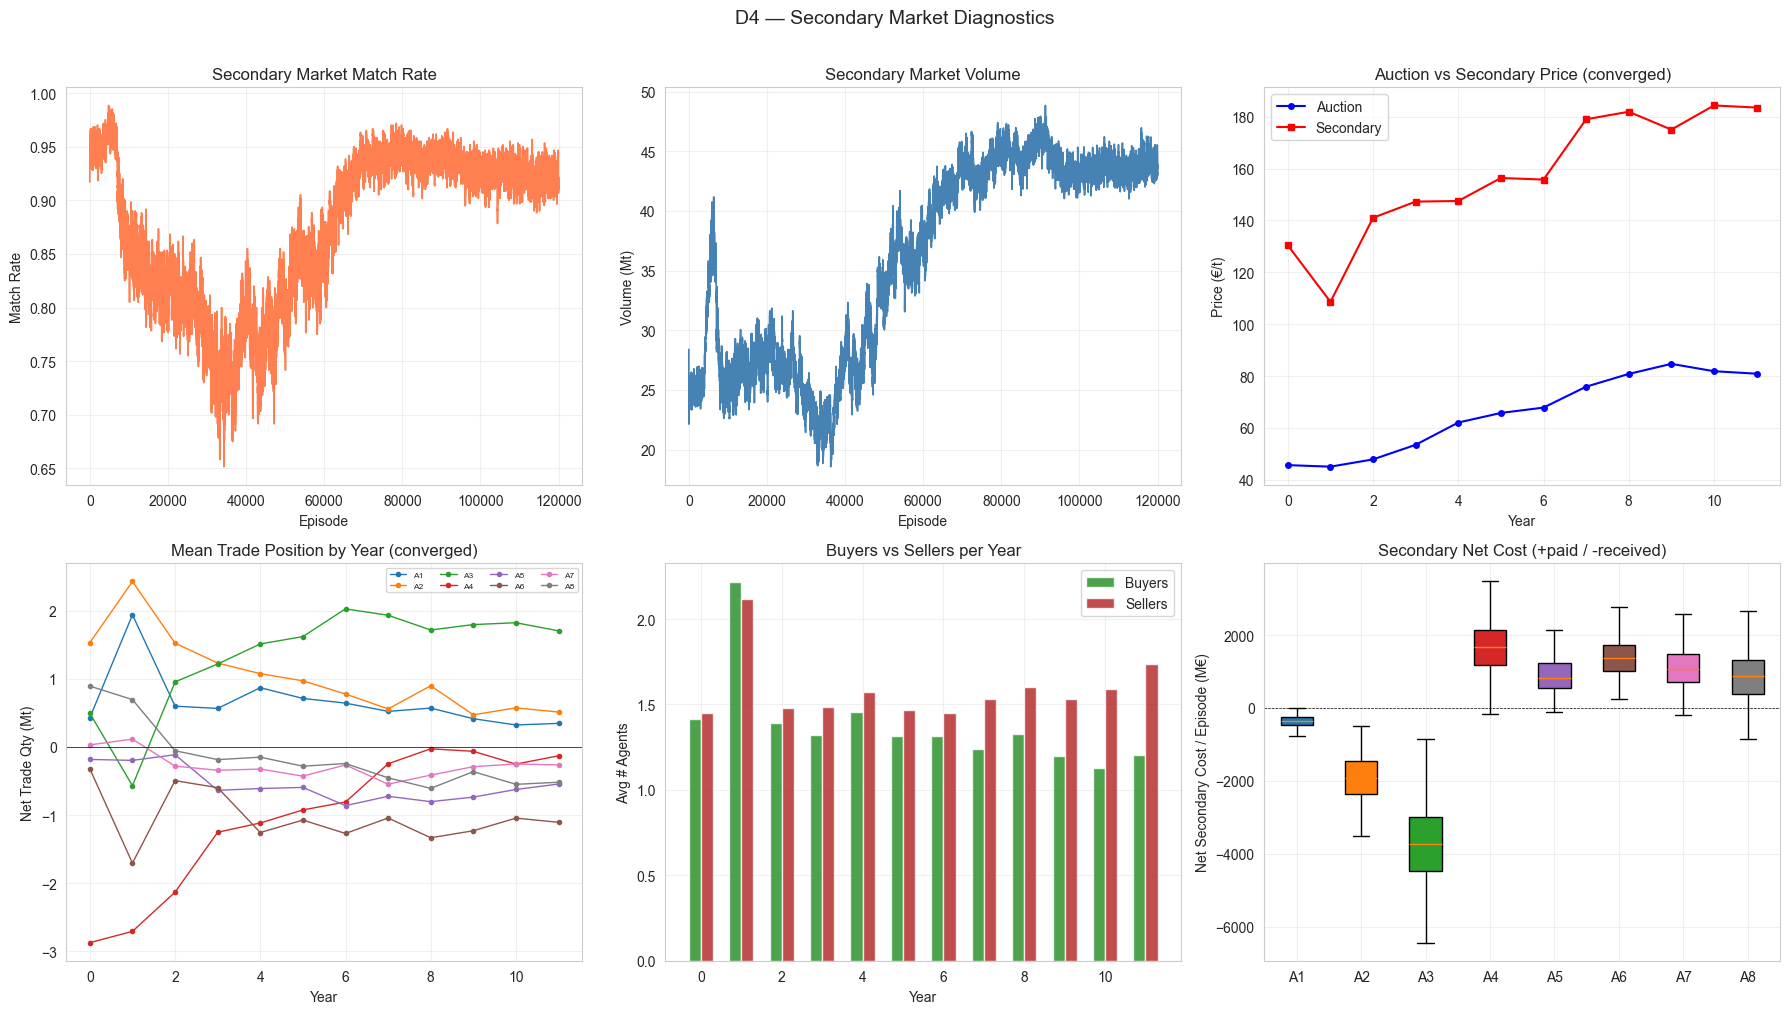

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Match rate / 2 — Volume over training
for ax, col, color, ylabel, title in [
    (axes[0, 0], 'secondary_match_rate', 'coral', 'Match Rate', 'Secondary Market Match Rate'),
    (axes[0, 1], 'secondary_volume', 'steelblue', 'Volume (Mt)', 'Secondary Market Volume'),
]:
    ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(), color=color, lw=1.2)
    ax.set(xlabel='Episode', ylabel=ylabel, title=title); ax.grid(True, alpha=0.3)

# 3 — Secondary vs Auction price
ax = axes[0, 2]
sec_mean_yr = recent_yr.groupby('year')['secondary_price'].mean()
auc_mean_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(auc_mean_yr.index, auc_mean_yr.values, 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(sec_mean_yr.index, sec_mean_yr.values, 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set(xlabel='Year', ylabel='Price (€/t)', title='Auction vs Secondary Price (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Net trade by agent×year
ax = axes[1, 0]
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    ax.plot(trade_by_yr.index, trade_by_yr.values, color=agent_colors[i], marker='o', ms=3, label=f'A{i+1}', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='Year', ylabel='Net Trade Qty (Mt)', title='Mean Trade Position by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Buyers vs sellers per year
ax = axes[1, 1]
buy_count_yr, sell_count_yr = [], []
for yr in range(n_years_per_ep):
    yr_data = recent_yr[recent_yr['year'] == yr]
    buy_count_yr.append(sum((yr_data[f'trade_qty_A{i+1}'] > 0.01).mean() for i in range(n_agents)))
    sell_count_yr.append(sum((yr_data[f'trade_qty_A{i+1}'] < -0.01).mean() for i in range(n_agents)))
x = np.arange(n_years_per_ep)
ax.bar(x - 0.15, buy_count_yr, 0.3, color='forestgreen', alpha=0.8, label='Buyers')
ax.bar(x + 0.15, sell_count_yr, 0.3, color='firebrick', alpha=0.8, label='Sellers')
ax.set(xlabel='Year', ylabel='Avg # Agents', title='Buyers vs Sellers per Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Secondary net cost distribution
ax = axes[1, 2]
snet_data = [recent_yr.groupby('episode')[f'secondary_net_A{i+1}'].sum().values for i in range(n_agents)]
bp = ax.boxplot(snet_data, tick_labels=[f'A{i+1}' for i in range(n_agents)], patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']): patch.set_facecolor(agent_colors[i])
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set(ylabel='Net Secondary Cost / Episode (M€)', title='Secondary Net Cost (+paid / -received)'); ax.grid(True, alpha=0.3)

plt.suptitle('D4 — Secondary Market Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D6. Compliance & Penalty Mechanics

Verify that compliance mechanics work:
- Shortfalls are detected and penalized
- Penalties are proportional to shortfall
- Banking (carry-over) functions correctly

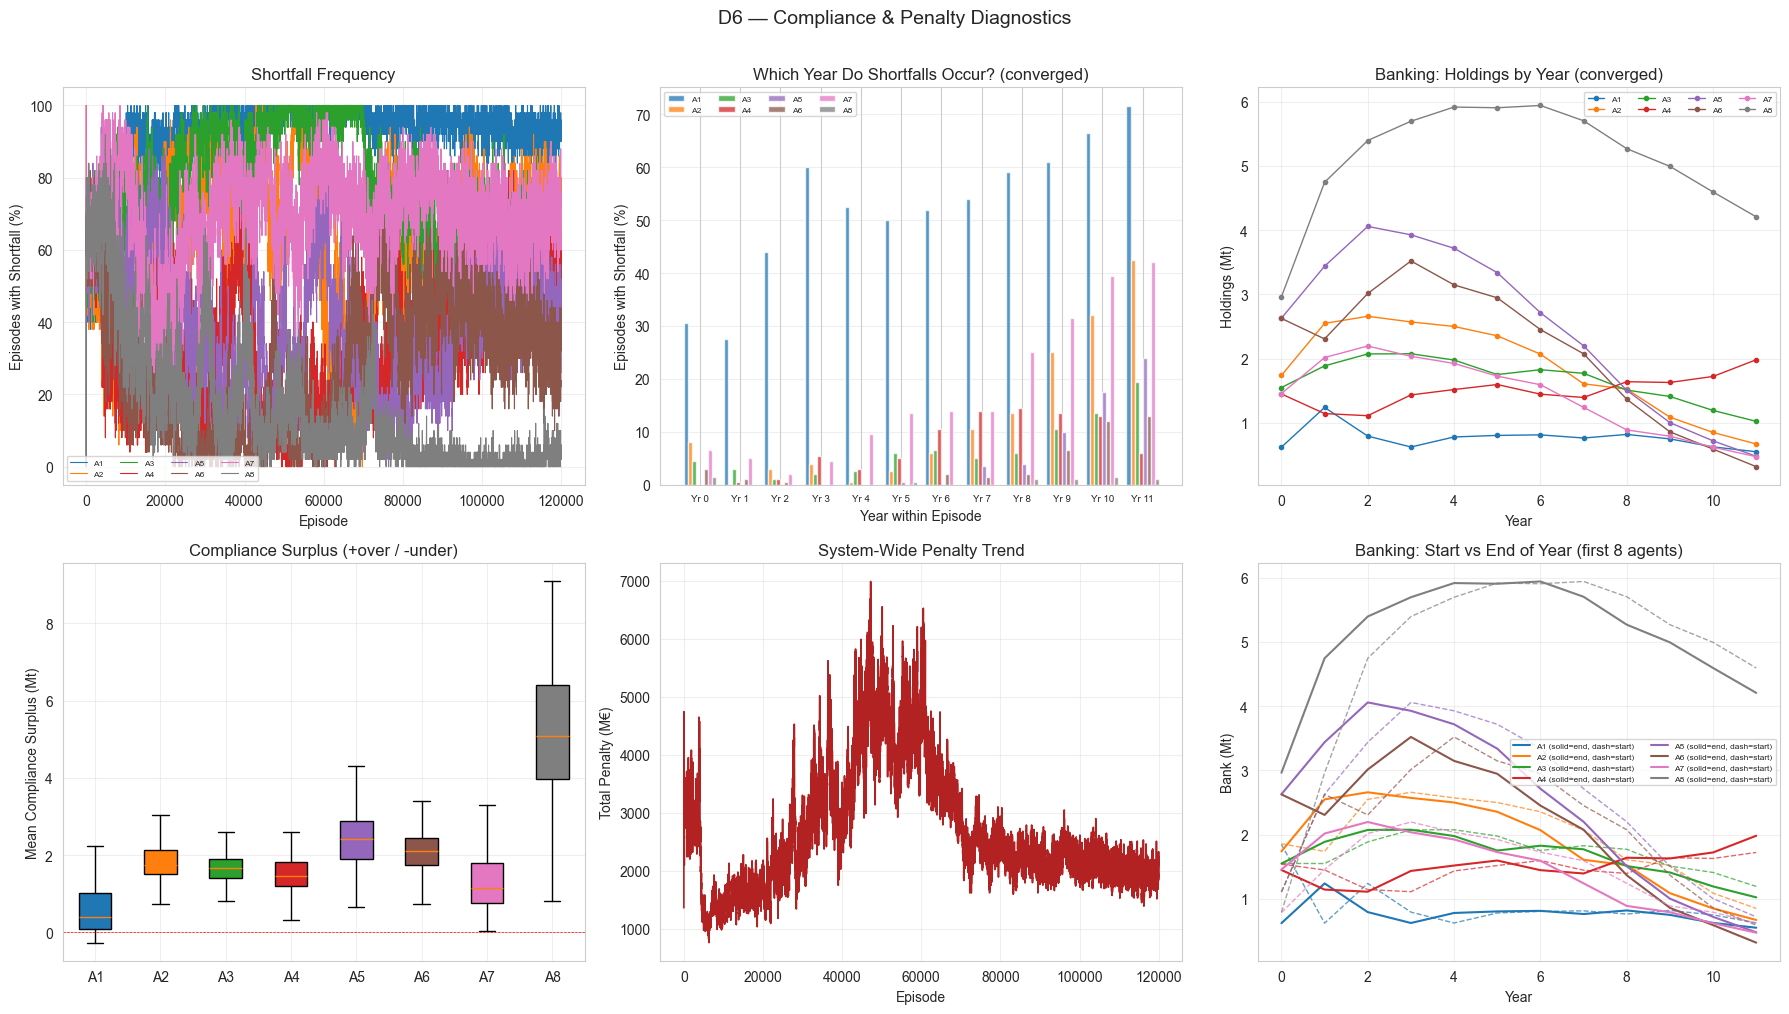

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Shortfall rate over training
ax = axes[0, 0]
for i in range(n_agents):
    sf = (ep_df[f'shortfall_A{i+1}'] > 1e-6).astype(float).rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf * 100, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set(xlabel='Episode', ylabel='Episodes with Shortfall (%)', title='Shortfall Frequency')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Shortfalls by year (converged)
ax = axes[0, 1]
years = sorted(recent_yr['year'].unique())
shortfall_by_year = {yr: [(recent_yr[recent_yr['year'] == yr][f'shortfall_A{i+1}'] > 1e-6).mean()
                          for i in range(n_agents)] for yr in years}
x = np.arange(len(years)); bar_w = 0.8 / max(n_agents, 1)
for i in range(n_agents):
    ax.bar(x + i * bar_w - 0.4 + bar_w / 2, [shortfall_by_year[yr][i] * 100 for yr in years],
           width=bar_w, color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
ax.set_xticks(x); ax.set_xticklabels([f'Yr {y}' for y in years], fontsize=7)
ax.set(xlabel='Year within Episode', ylabel='Episodes with Shortfall (%)', title='Which Year Do Shortfalls Occur? (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3, axis='y')

# 3 — Holdings by year (banking)
ax = axes[0, 2]
for i in range(n_agents):
    hold_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(hold_yr.index, hold_yr.values, color=agent_colors[i], marker='o', ms=3, label=f'A{i+1}', lw=1)
ax.set(xlabel='Year', ylabel='Holdings (Mt)', title='Banking: Holdings by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Compliance surplus distribution
ax = axes[1, 0]
if 'compliance_surplus_A1' in recent_yr.columns:
    surp_data = [recent_yr.groupby('episode')[f'compliance_surplus_A{i+1}'].mean().values for i in range(n_agents)]
    bp = ax.boxplot(surp_data, tick_labels=[f'A{i+1}' for i in range(n_agents)], patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']): patch.set_facecolor(agent_colors[i])
    ax.axhline(0, color='red', ls='--', lw=0.5)
    ax.set(ylabel='Mean Compliance Surplus (Mt)', title='Compliance Surplus (+over / -under)')
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Total penalty over training
ax = axes[1, 1]
total_pen = ep_df[[f'penalty_A{i+1}' for i in range(n_agents)]].sum(axis=1)
ax.plot(ep_df['episode'], total_pen.rolling(ROLL, min_periods=1).mean(), color='firebrick', lw=1.2)
ax.set(xlabel='Episode', ylabel='Total Penalty (M€)', title='System-Wide Penalty Trend'); ax.grid(True, alpha=0.3)

# 6 — Bank start vs end (carry-forward)
ax = axes[1, 2]
if 'bank_end_A1' in recent_yr.columns and 'bank_start_A1' in recent_yr.columns:
    for i in range(min(8, n_agents)):
        bs = recent_yr.groupby('year')[f'bank_start_A{i+1}'].mean()
        be = recent_yr.groupby('year')[f'bank_end_A{i+1}'].mean()
        ax.plot(bs.index, bs.values, color=agent_colors[i], ls='--', lw=1, alpha=0.7)
        ax.plot(be.index, be.values, color=agent_colors[i], ls='-', lw=1.5, label=f'A{i+1} (solid=end, dash=start)')
    ax.set(xlabel='Year', ylabel='Bank (Mt)', title='Banking: Start vs End of Year (first 8 agents)')
    ax.legend(fontsize=6, ncol=2)
else:
    ax.text(0.5, 0.5, 'bank_end not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('D6 — Compliance & Penalty Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D8. Final-Year Invested Assets, Queue State, and Liquidation Payoff

> This cell now prioritizes liquidation values logged directly from the environment reward computation into year_log CSV.

> Fallback behavior:
> - If `terminal_*_value_A*` columns are absent (older logs), bank liquidation is reconstructed from bank_end × clearing_price / 1000.
> - Queue liquidation is shown only if logged columns exist.

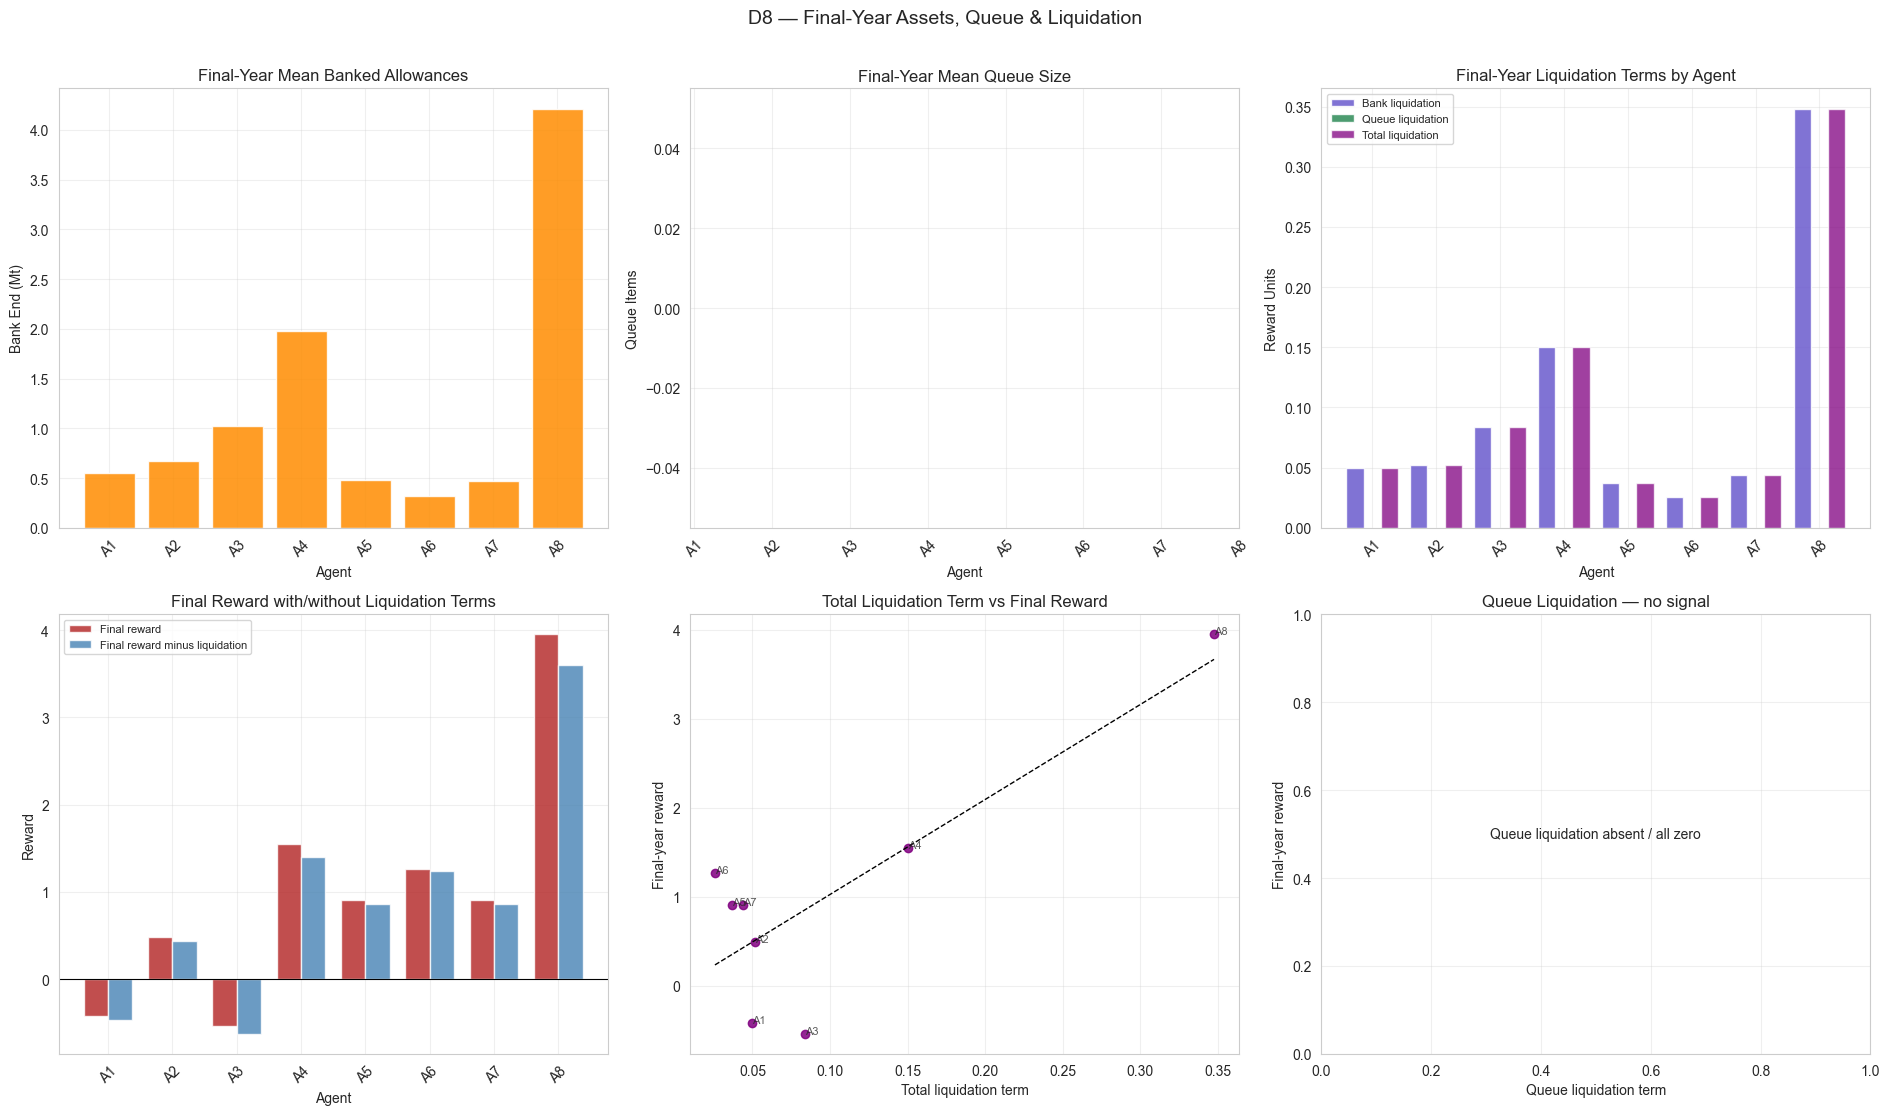

In [25]:
# D8: Final-Year Invested Assets, Queue State, and Liquidation Payoff
reward_cols_all = sorted([c for c in recent_yr.columns if c.startswith('reward_A')], key=lambda x: int(x.split('_A')[1]))
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))
y_last = int(recent_yr['year'].max())
final_slice = recent_yr[recent_yr['year'] == y_last].copy()
reward_cfg = config.get('reward', {})
terminal_bank_enabled = bool(reward_cfg.get('terminal_bank_value', False))

agent_lbls_d8, final_reward_vals = [], []
bank_end_vals, queue_end_vals = [], []
bank_liq_vals, queue_liq_vals, total_liq_vals = [], [], []

for i in agent_ids_logged:
    r_col, b_col, q_col = f'reward_A{i}', f'bank_end_A{i}', f'queue_size_A{i}'
    b_liq_col, q_liq_col, t_liq_col = f'terminal_bank_value_A{i}', f'terminal_queue_value_A{i}', f'terminal_liquidation_value_A{i}'
    if r_col not in final_slice.columns:
        continue
    rf = float(final_slice[r_col].mean())
    be = float(final_slice[b_col].mean()) if b_col in final_slice.columns else np.nan
    qe = float(final_slice[q_col].mean()) if q_col in final_slice.columns else np.nan
    if t_liq_col in final_slice.columns:
        t_liq = float(final_slice[t_liq_col].mean())
        b_liq = float(final_slice[b_liq_col].mean()) if b_liq_col in final_slice.columns else np.nan
        q_liq = float(final_slice[q_liq_col].mean()) if q_liq_col in final_slice.columns else np.nan
    else:
        # Fallback for old logs.
        b_liq = float((final_slice[b_col] * final_slice['clearing_price'] / 1000.0).mean()) \
            if (terminal_bank_enabled and b_col in final_slice.columns and 'clearing_price' in final_slice.columns) else 0.0
        q_liq = 0.0; t_liq = b_liq + q_liq
    agent_lbls_d8.append(f'A{i}')
    final_reward_vals.append(rf); bank_end_vals.append(be); queue_end_vals.append(qe)
    bank_liq_vals.append(b_liq); queue_liq_vals.append(q_liq); total_liq_vals.append(t_liq)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
x = np.arange(len(agent_lbls_d8))

axes[0, 0].bar(x, bank_end_vals, color='darkorange', alpha=0.85)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(agent_lbls_d8, rotation=45)
axes[0, 0].set(xlabel='Agent', ylabel='Bank End (Mt)', title='Final-Year Mean Banked Allowances'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].bar(x, queue_end_vals, color='teal', alpha=0.85)
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(agent_lbls_d8, rotation=45)
axes[0, 1].set(xlabel='Agent', ylabel='Queue Items', title='Final-Year Mean Queue Size'); axes[0, 1].grid(True, alpha=0.3)

ax = axes[0, 2]; w = 0.27
ax.bar(x - w, bank_liq_vals, w, color='slateblue', alpha=0.85, label='Bank liquidation')
ax.bar(x,     queue_liq_vals, w, color='seagreen', alpha=0.85, label='Queue liquidation')
ax.bar(x + w, total_liq_vals, w, color='purple', alpha=0.75, label='Total liquidation')
ax.set_xticks(x); ax.set_xticklabels(agent_lbls_d8, rotation=45)
ax.set(xlabel='Agent', ylabel='Reward Units', title='Final-Year Liquidation Terms by Agent')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 0]; w = 0.38
rew_minus_liq = [r - l for r, l in zip(final_reward_vals, total_liq_vals)]
ax.bar(x - w / 2, final_reward_vals, w, color='firebrick', alpha=0.8, label='Final reward')
ax.bar(x + w / 2, rew_minus_liq,    w, color='steelblue', alpha=0.8, label='Final reward minus liquidation')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(agent_lbls_d8, rotation=45)
ax.set(xlabel='Agent', ylabel='Reward', title='Final Reward with/without Liquidation Terms')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
if total_liq_vals:
    ax.scatter(total_liq_vals, final_reward_vals, s=36, color='purple', alpha=0.85)
    for xv, yv, lbl in zip(total_liq_vals, final_reward_vals, agent_lbls_d8):
        ax.text(xv, yv, lbl, fontsize=8, alpha=0.75)
    if len(total_liq_vals) > 2 and np.std(total_liq_vals) > 1e-12:
        m = np.polyfit(total_liq_vals, final_reward_vals, 1)
        xfit = np.linspace(min(total_liq_vals), max(total_liq_vals), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
ax.set(xlabel='Total liquidation term', ylabel='Final-year reward', title='Total Liquidation Term vs Final Reward')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
qarr = np.array(queue_liq_vals, dtype=float)
if np.isfinite(qarr).any() and np.nansum(np.abs(qarr)) > 0:
    ax.scatter(queue_liq_vals, final_reward_vals, s=36, color='seagreen', alpha=0.85)
    for xv, yv, lbl in zip(queue_liq_vals, final_reward_vals, agent_lbls_d8):
        ax.text(xv, yv, lbl, fontsize=8, alpha=0.75)
    ax.set_title('Queue Liquidation Term vs Final Reward')
else:
    ax.text(0.5, 0.5, 'Queue liquidation absent / all zero', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Queue Liquidation — no signal')
ax.set(xlabel='Queue liquidation term', ylabel='Final-year reward'); ax.grid(True, alpha=0.3)

plt.suptitle('D8 — Final-Year Assets, Queue & Liquidation', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D5. Stochastic Shocks (P5 & P6)

Verify that emission demand shocks (P5) and construction uncertainty (P6) are
active and producing the intended distributions.

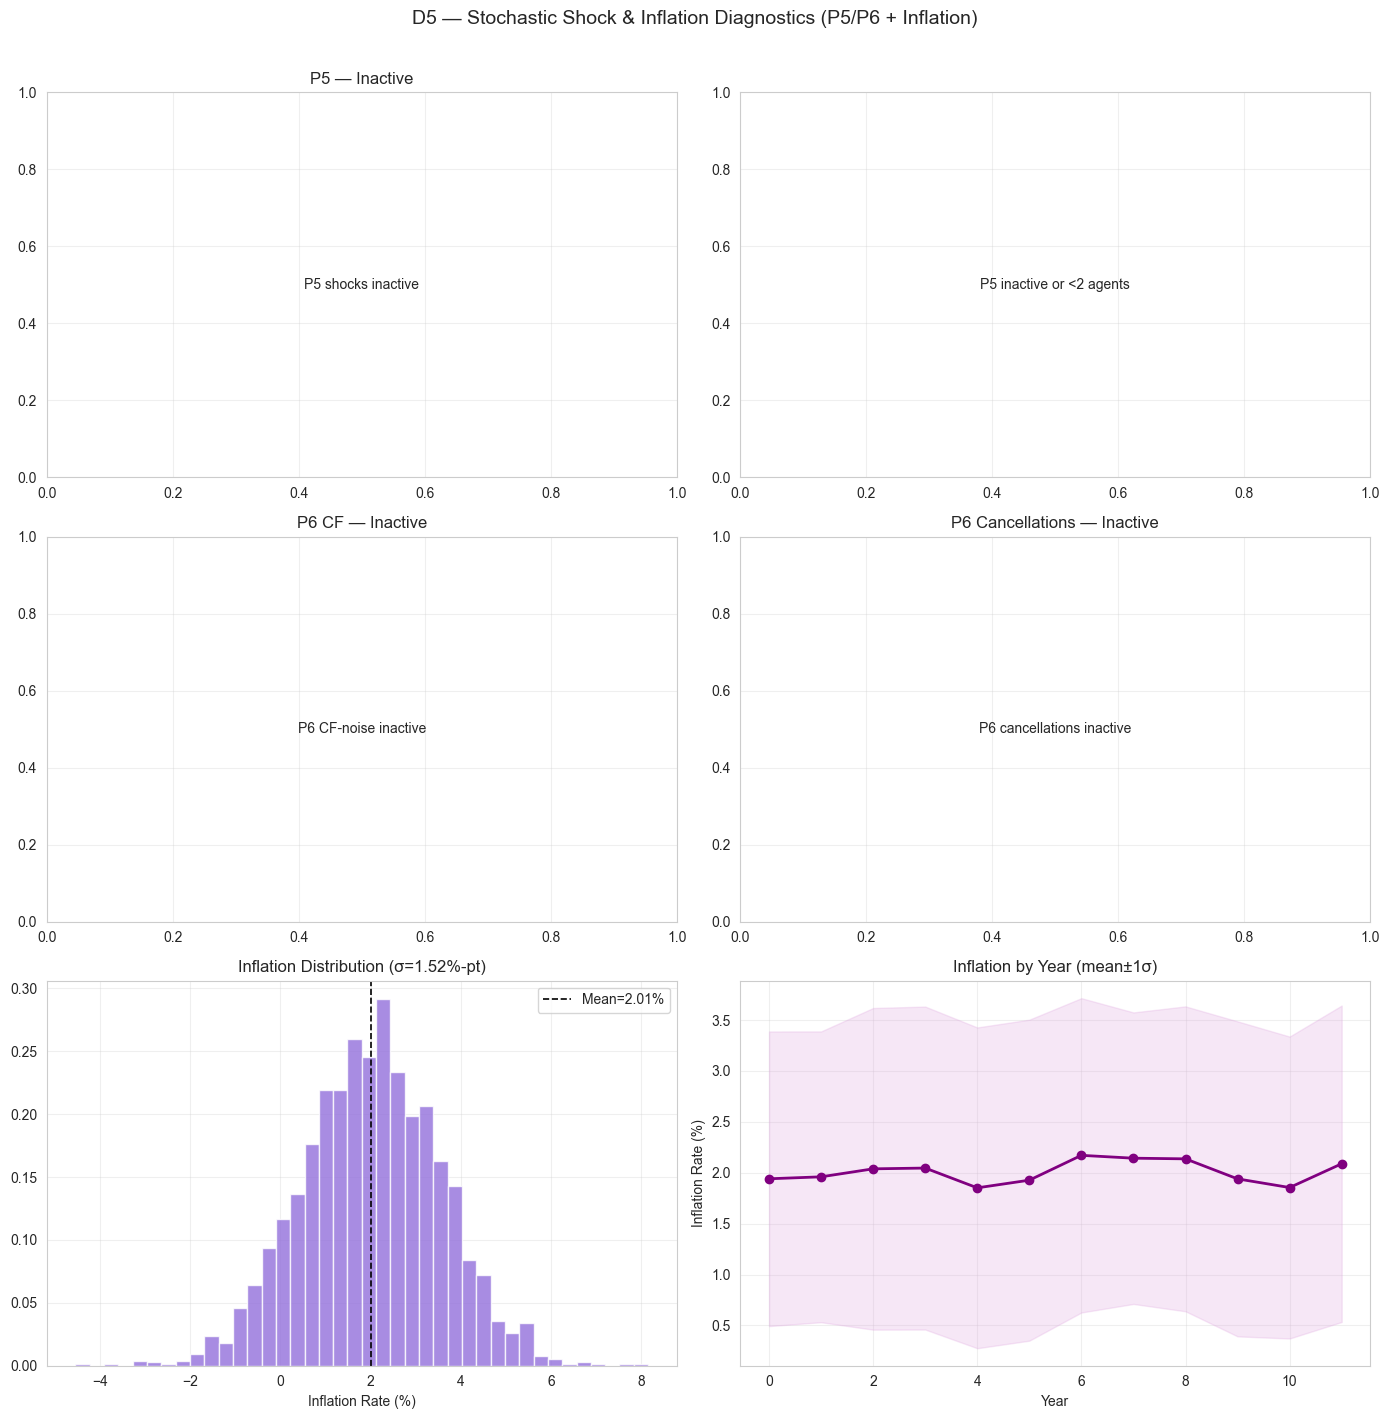

P5 emission shock active: False
P6 CF-noise active:       False
P6 cancellation active:   False
Inflation logged:         True
Inflation mean:           2.008%
Inflation std:            1.523%-pt


In [26]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
shock_cols = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols = [f'cf_shock_A{i+1}' for i in range(n_agents)]
cancel_cols = [f'cancellation_A{i+1}' for i in range(n_agents)]
has_shocks = any(c in recent_yr.columns for c in shock_cols) and recent_yr[shock_cols[0]].std() > 1e-6
has_cf = any(c in recent_yr.columns for c in cf_cols) and recent_yr[cf_cols[0]].std() > 1e-8
has_cancel = any(c in recent_yr.columns for c in cancel_cols) and recent_yr[cancel_cols[0]].sum() > 0
has_infl = 'inflation_rate' in recent_yr.columns and recent_yr['inflation_rate'].notna().any()

# 1 — P5 shock distribution
ax = axes[0, 0]
if has_shocks:
    all_shocks = pd.concat([recent_yr[c] * 100 for c in shock_cols if c in recent_yr.columns])
    ax.hist(all_shocks, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set(xlabel='Emission Shock ε (%)', title=f'P5 Shock Distribution (σ={all_shocks.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P5 shocks inactive', ha='center', va='center', transform=ax.transAxes); ax.set_title('P5 — Inactive')
ax.grid(True, alpha=0.3)

# 2 — P5 cross-agent correlation
ax = axes[0, 1]
if has_shocks and n_agents >= 2:
    s1, s2 = recent_yr[shock_cols[0]] * 100, recent_yr[shock_cols[1]] * 100
    ax.scatter(s1, s2, alpha=0.05, s=5, color='steelblue')
    ax.set(xlabel='A1 shock (%)', ylabel='A2 shock (%)', title=f'P5 Cross-Agent Correlation (ρ={s1.corr(s2):.2f})')
else:
    ax.text(0.5, 0.5, 'P5 inactive or <2 agents', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 3 — P6 CF noise
ax = axes[1, 0]
if has_cf:
    all_cf = pd.concat([recent_yr[c] * 100 for c in cf_cols if c in recent_yr.columns])
    ax.hist(all_cf, bins=60, color='seagreen', edgecolor='white', alpha=0.8, density=True)
    ax.set(xlabel='CF Noise (%)', title=f'P6 Capacity-Factor Noise (σ={all_cf.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P6 CF-noise inactive', ha='center', va='center', transform=ax.transAxes); ax.set_title('P6 CF — Inactive')
ax.grid(True, alpha=0.3)

# 4 — P6 cancellations
ax = axes[1, 1]
if has_cancel:
    cancel_per_ep = recent_yr.groupby('episode')[cancel_cols].sum().sum(axis=1)
    ax.hist(cancel_per_ep, bins=30, color='coral', edgecolor='white', alpha=0.8)
    ax.set(xlabel='Total Cancellations / Episode', title=f'P6 Project Cancellations (mean={cancel_per_ep.mean():.1f}/ep)')
else:
    ax.text(0.5, 0.5, 'P6 cancellations inactive', ha='center', va='center', transform=ax.transAxes); ax.set_title('P6 Cancellations — Inactive')
ax.grid(True, alpha=0.3)

# 5 — Inflation distribution
ax = axes[2, 0]
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    ax.hist(infl_pct, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(infl_pct.mean(), color='black', ls='--', lw=1.2, label=f'Mean={infl_pct.mean():.2f}%')
    ax.set(xlabel='Inflation Rate (%)', title=f'Inflation Distribution (σ={infl_pct.std():.2f}%-pt)'); ax.legend()
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes); ax.set_title('Inflation — Not Available')
ax.grid(True, alpha=0.3)

# 6 — Inflation profile by year
ax = axes[2, 1]
if has_infl:
    infl_by_year = recent_yr.groupby('year')['inflation_rate'].agg(['mean', 'std']) * 100
    std_fill = infl_by_year['std'].fillna(0.0)
    ax.plot(infl_by_year.index, infl_by_year['mean'], color='purple', marker='o', lw=2)
    ax.fill_between(infl_by_year.index, infl_by_year['mean'] - std_fill, infl_by_year['mean'] + std_fill, color='plum', alpha=0.25)
    ax.set(xlabel='Year', ylabel='Inflation Rate (%)', title='Inflation by Year (mean±1σ)')
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes); ax.set_title('Inflation by Year — Not Available')
ax.grid(True, alpha=0.3)

plt.suptitle('D5 — Stochastic Shock & Inflation Diagnostics (P5/P6 + Inflation)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print(f'P5 emission shock active: {has_shocks}')
print(f'P6 CF-noise active:       {has_cf}')
print(f'P6 cancellation active:   {has_cancel}')
print(f'Inflation logged:         {has_infl}')
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    print(f'Inflation mean:           {infl_pct.mean():.3f}%')
    print(f'Inflation std:            {infl_pct.std():.3f}%-pt')


---
# Part II — Strategy Deep Dive (A)

> *What strategies did the agents learn and why?*

Drops the bot-comparison section (A7 / A7a) and the standalone summary /
troubleshooting digest. The standalone collateral panel (A5b) is removed;
collateral is folded into the cost-breakdown panel of §A5.


### A1. Auction Bidding Strategy

How agents bid in the primary EUA auction:
- **Price discovery** — do bids converge to a common clearing price?
- **Quantity strategy** — do agents bid for what they need or over/under-bid?
- **Archetype differences** — do coal-heavy agents bid differently from near-green?

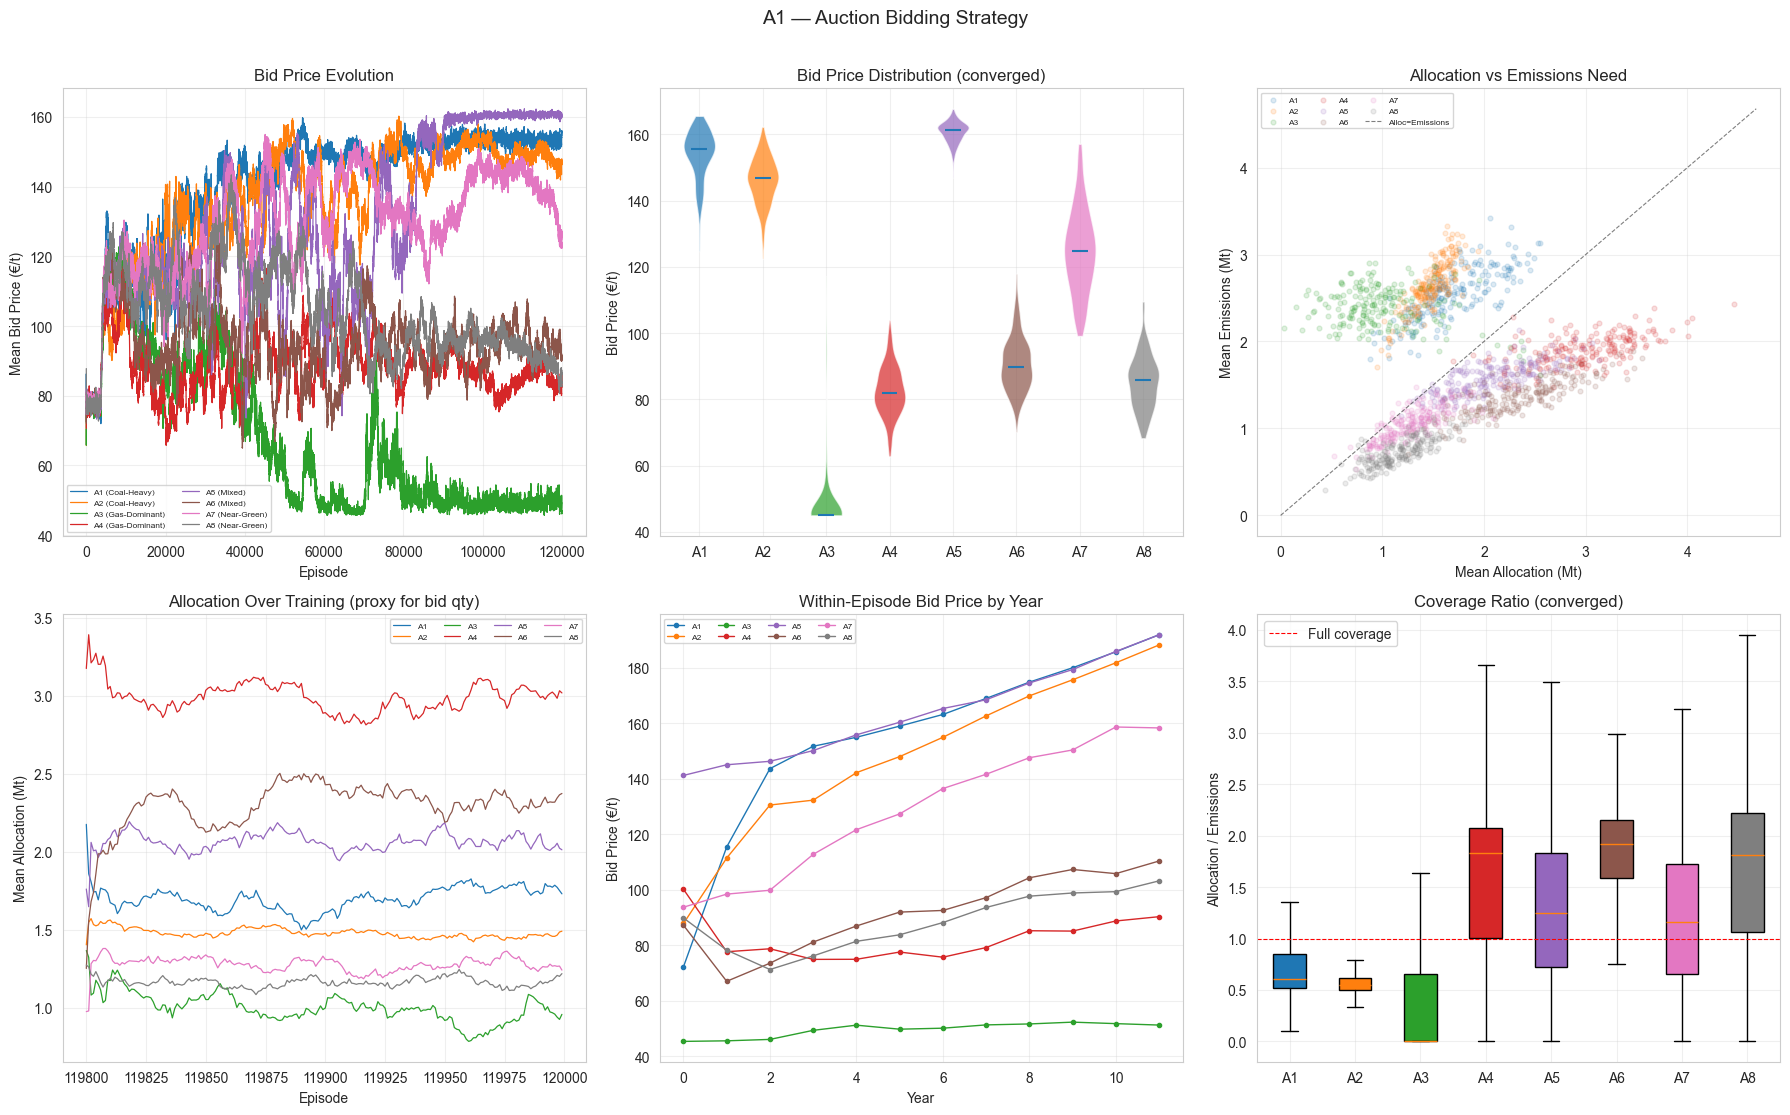

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Bid price evolution
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.set(xlabel='Episode', ylabel='Mean Bid Price (€/t)', title='Bid Price Evolution')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Bid price distribution (converged)
ax = axes[0, 1]
parts = ax.violinplot([recent_ep[f'bid_price_A{i+1}'].values for i in range(n_agents)],
                      positions=range(n_agents), showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']): pc.set_facecolor(agent_colors[i]); pc.set_alpha(0.7)
ax.set_xticks(range(n_agents)); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set(ylabel='Bid Price (€/t)', title='Bid Price Distribution (converged)'); ax.grid(True, alpha=0.3)

# 3 — Allocation vs Emissions scatter
ax = axes[0, 2]
for i in range(n_agents):
    allocs = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    emiss = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(allocs, emiss, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='Alloc=Emissions')
ax.set(xlabel='Mean Allocation (Mt)', ylabel='Mean Emissions (Mt)', title='Allocation vs Emissions Need')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Allocation over training (proxy for bid qty)
ax = axes[1, 0]
for i in range(n_agents):
    alloc_smooth = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean().rolling(ROLL // 2, min_periods=1).mean()
    ax.plot(alloc_smooth.index, alloc_smooth.values, color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set(xlabel='Episode', ylabel='Mean Allocation (Mt)', title='Allocation Over Training (proxy for bid qty)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Bid price by year within episode
ax = axes[1, 1]
for i in range(n_agents):
    bid_yr = recent_yr.groupby('year')[f'bid_price_A{i+1}'].mean()
    ax.plot(bid_yr.index, bid_yr.values, color=agent_colors[i], marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.set(xlabel='Year', ylabel='Bid Price (€/t)', title='Within-Episode Bid Price by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Coverage ratio: alloc / emissions
ax = axes[1, 2]
cov_data = [(recent_yr[f'alloc_A{i+1}'] / recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)).dropna().values
            for i in range(n_agents)]
bp = ax.boxplot(cov_data, tick_labels=[f'A{i+1}' for i in range(n_agents)], patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']): patch.set_facecolor(agent_colors[i])
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Full coverage')
ax.set(ylabel='Allocation / Emissions', title='Coverage Ratio (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('A1 — Auction Bidding Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A2. Secondary Market Strategy

How agents trade on the secondary market:
- **Role evolution** — who becomes a net buyer vs seller over training?
- **Year-by-year patterns** — do roles shift within an episode as the cap tightens?
- **Price premiums** — secondary vs auction price spread
- **Cost/revenue** — who profits from secondary trading?

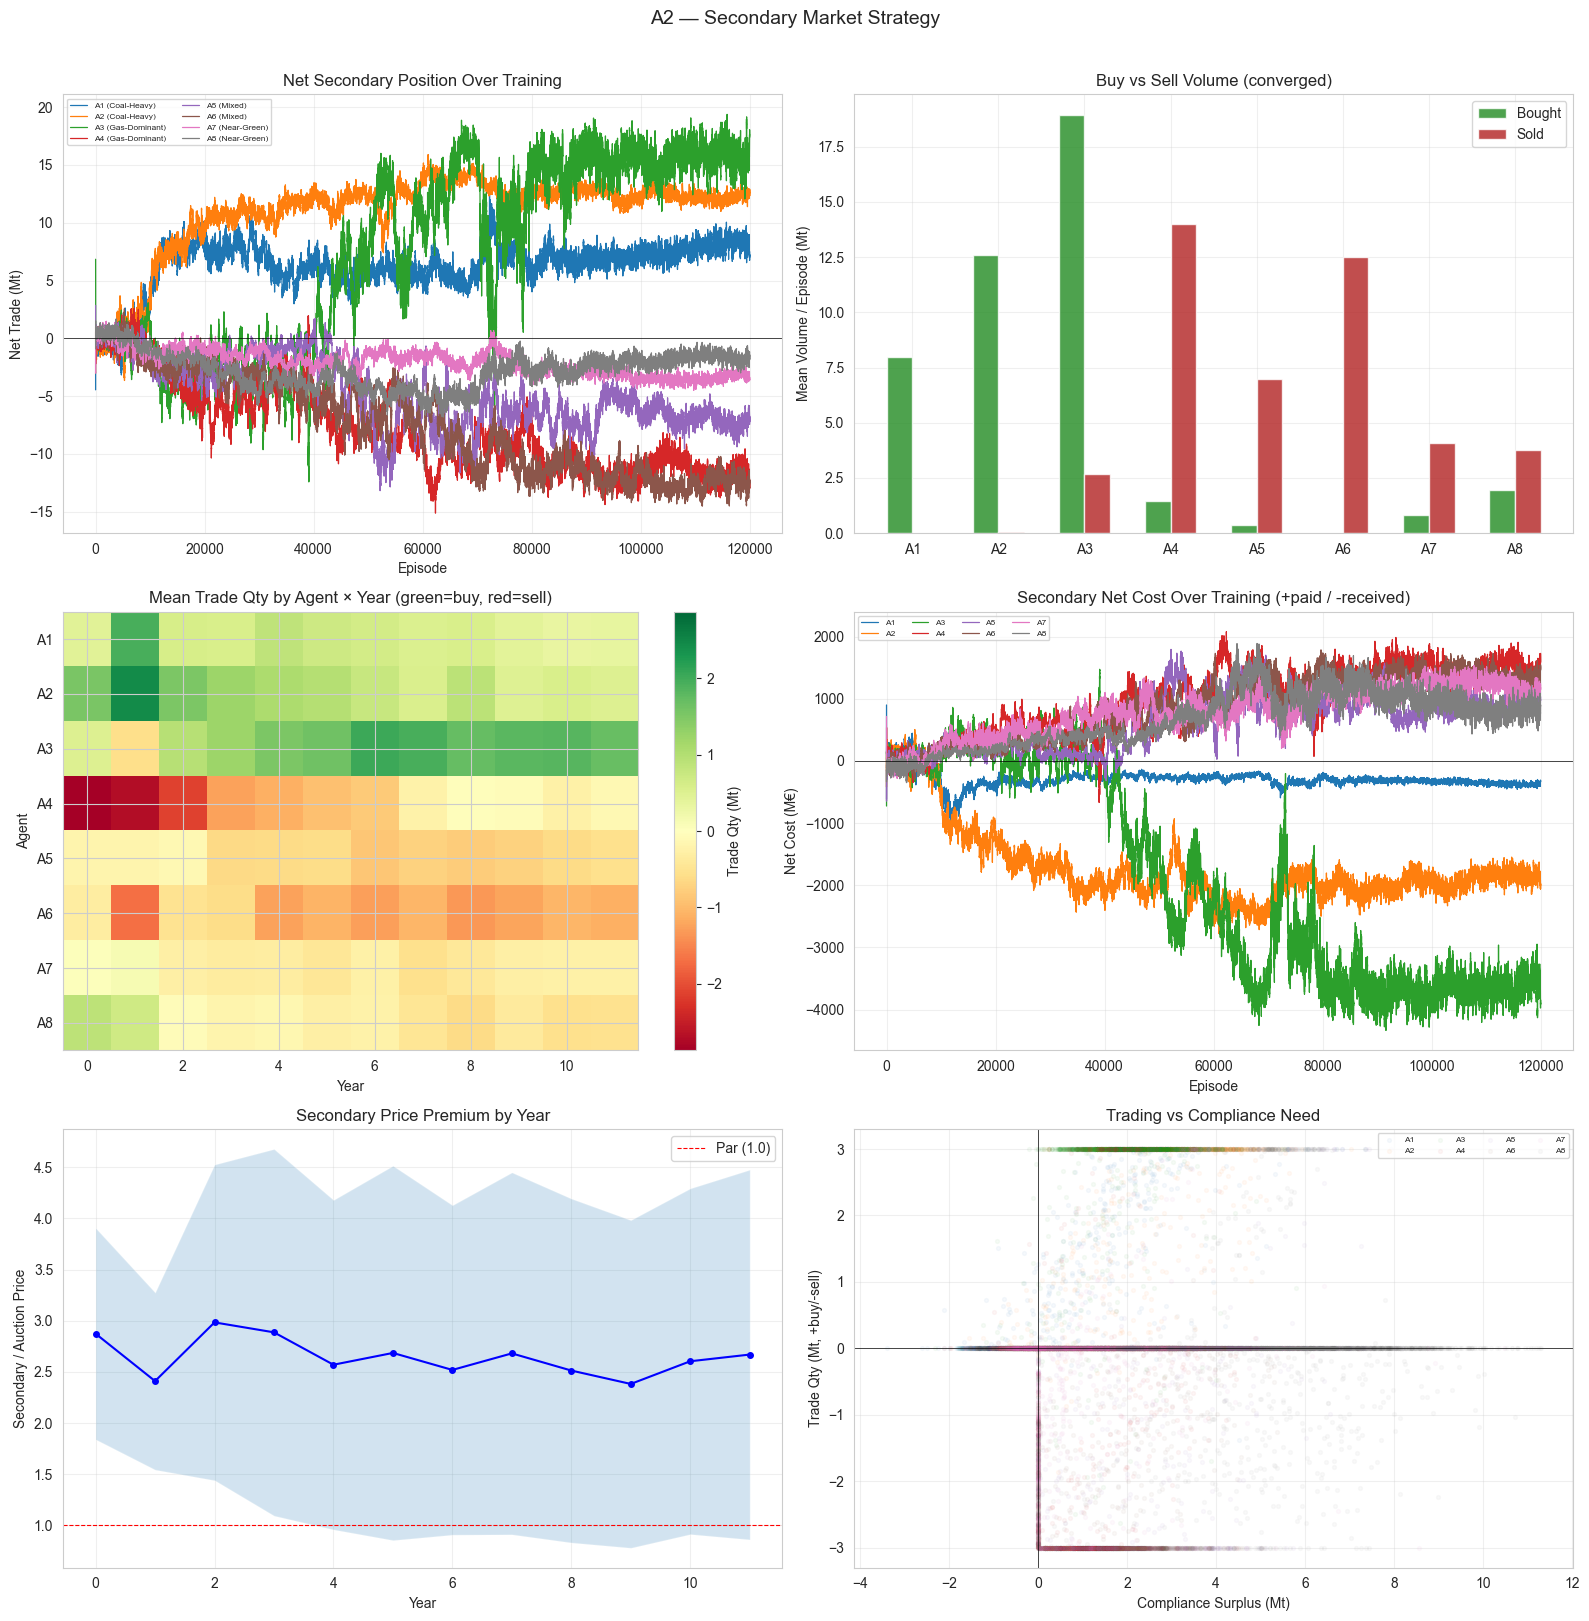

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1 — Net trade position over training
ax = axes[0, 0]
for i in range(n_agents):
    net_trade = yr_df.groupby('episode')[f'trade_qty_A{i+1}'].sum()
    ax.plot(net_trade.index, net_trade.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='Episode', ylabel='Net Trade (Mt)', title='Net Secondary Position Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Buy vs sell volume per agent (converged)
ax = axes[0, 1]
buy_vols, sell_vols = [], []
for i in range(n_agents):
    tq = recent_yr[f'trade_qty_A{i+1}']
    buy_vols.append(tq[tq > 0.01].sum() / LAST_N)
    sell_vols.append(abs(tq[tq < -0.01].sum()) / LAST_N)
x = np.arange(n_agents)
ax.bar(x - 0.15, buy_vols, 0.3, color='forestgreen', alpha=0.8, label='Bought')
ax.bar(x + 0.15, sell_vols, 0.3, color='firebrick', alpha=0.8, label='Sold')
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set(ylabel='Mean Volume / Episode (Mt)', title='Buy vs Sell Volume (converged)')
ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Trade matrix heatmap
ax = axes[1, 0]
trade_matrix = np.zeros((n_agents, n_years_per_ep))
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    trade_matrix[i, :len(trade_by_yr)] = trade_by_yr.values
vmax = max(abs(trade_matrix.min()), abs(trade_matrix.max()))
im = ax.imshow(trade_matrix, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(n_agents)); ax.set_yticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set(xlabel='Year', ylabel='Agent', title='Mean Trade Qty by Agent × Year (green=buy, red=sell)')
plt.colorbar(im, ax=ax, label='Trade Qty (Mt)')

# 4 — Net secondary cost over training
ax = axes[1, 1]
for i in range(n_agents):
    snet = yr_df.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    ax.plot(snet.index, snet.rolling(ROLL, min_periods=1).mean(), color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='Episode', ylabel='Net Cost (M€)', title='Secondary Net Cost Over Training (+paid / -received)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Secondary price premium over auction
ax = axes[2, 0]
premium = recent_yr['secondary_price'] / recent_yr['clearing_price'].replace(0, np.nan)
premium_yr = premium.groupby(recent_yr['year']).agg(['mean', 'std'])
ax.plot(premium_yr.index, premium_yr['mean'], 'b-o', ms=4, lw=1.5)
ax.fill_between(premium_yr.index, premium_yr['mean'] - premium_yr['std'], premium_yr['mean'] + premium_yr['std'], alpha=0.2)
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Par (1.0)')
ax.set(xlabel='Year', ylabel='Secondary / Auction Price', title='Secondary Price Premium by Year')
ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Trade qty vs compliance surplus
ax = axes[2, 1]
if 'compliance_surplus_A1' in recent_yr.columns:
    for i in range(n_agents):
        ax.scatter(recent_yr[f'compliance_surplus_A{i+1}'], recent_yr[f'trade_qty_A{i+1}'],
                   alpha=0.04, s=8, color=agent_colors[i], label=f'A{i+1}')
    ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
    ax.set(xlabel='Compliance Surplus (Mt)', ylabel='Trade Qty (Mt, +buy/-sell)', title='Trading vs Compliance Need')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('A2 — Secondary Market Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A3. Green Transition Strategy

Investment patterns in renewable energy:
- **Transition speed** — how quickly does each archetype green its portfolio?
- **Investment intensity** — how aggressively do agents invest?
- **Technology preference** — onshore wind, offshore wind, or solar?
- **Construction pipeline** — queuing effects and timing

C:\Users\danie\AppData\Local\Temp\ipykernel_23368\2584886982.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)


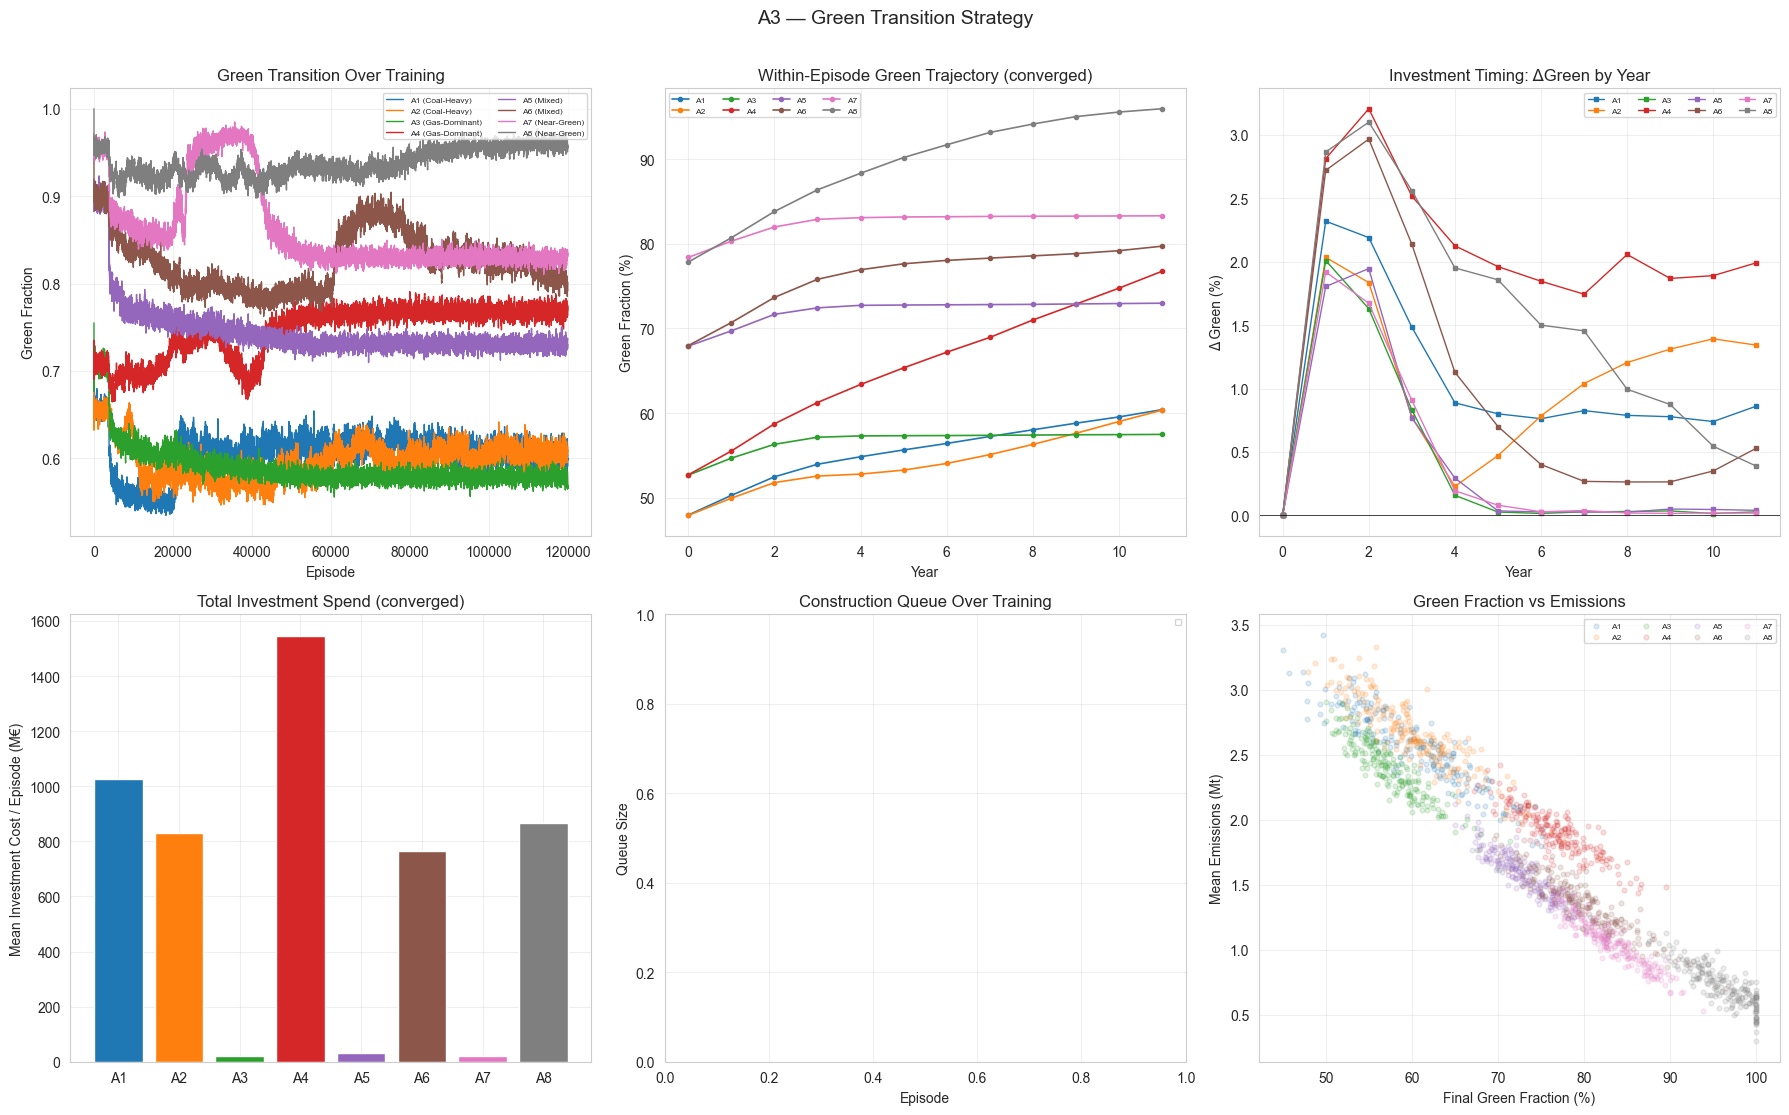

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction evolution over training
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=1, label=agent_labels[i])
ax.set(xlabel='Episode', ylabel='Green Fraction', title='Green Transition Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode
ax = axes[0, 1]
for i in range(n_agents):
    gf_yr = recent_yr.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set(xlabel='Year', ylabel='Green Fraction (%)', title='Within-Episode Green Trajectory (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Δgreen by year (when do agents invest?)
ax = axes[0, 2]
for i in range(n_agents):
    dg_yr = recent_yr.groupby('year')[f'delta_green_A{i+1}'].mean() * 100
    ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3, lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='Year', ylabel='Δ Green (%)', title='Investment Timing: ΔGreen by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_means = [recent_yr.groupby('episode')[f'invest_cost_A{i+1}'].sum().mean() for i in range(n_agents)]
ax.bar([f'A{i+1}' for i in range(n_agents)], inv_means, color=agent_colors)
ax.set(ylabel='Mean Investment Cost / Episode (M€)', title='Total Investment Spend (converged)'); ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set(xlabel='Episode', ylabel='Queue Size', title='Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
for i in range(n_agents):
    gf = recent_yr.groupby('episode')[f'green_frac_A{i+1}'].last()
    em = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(gf * 100, em, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set(xlabel='Final Green Fraction (%)', ylabel='Mean Emissions (Mt)', title='Green Fraction vs Emissions')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A3 — Green Transition Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A4. Compliance & Banking Strategy

How agents manage their allowance portfolio:
- **Banking** — accumulating surplus for future compliance
- **Shortfall avoidance** — learning to stay compliant
- **Risk management** — holdings buffer vs cost minimization

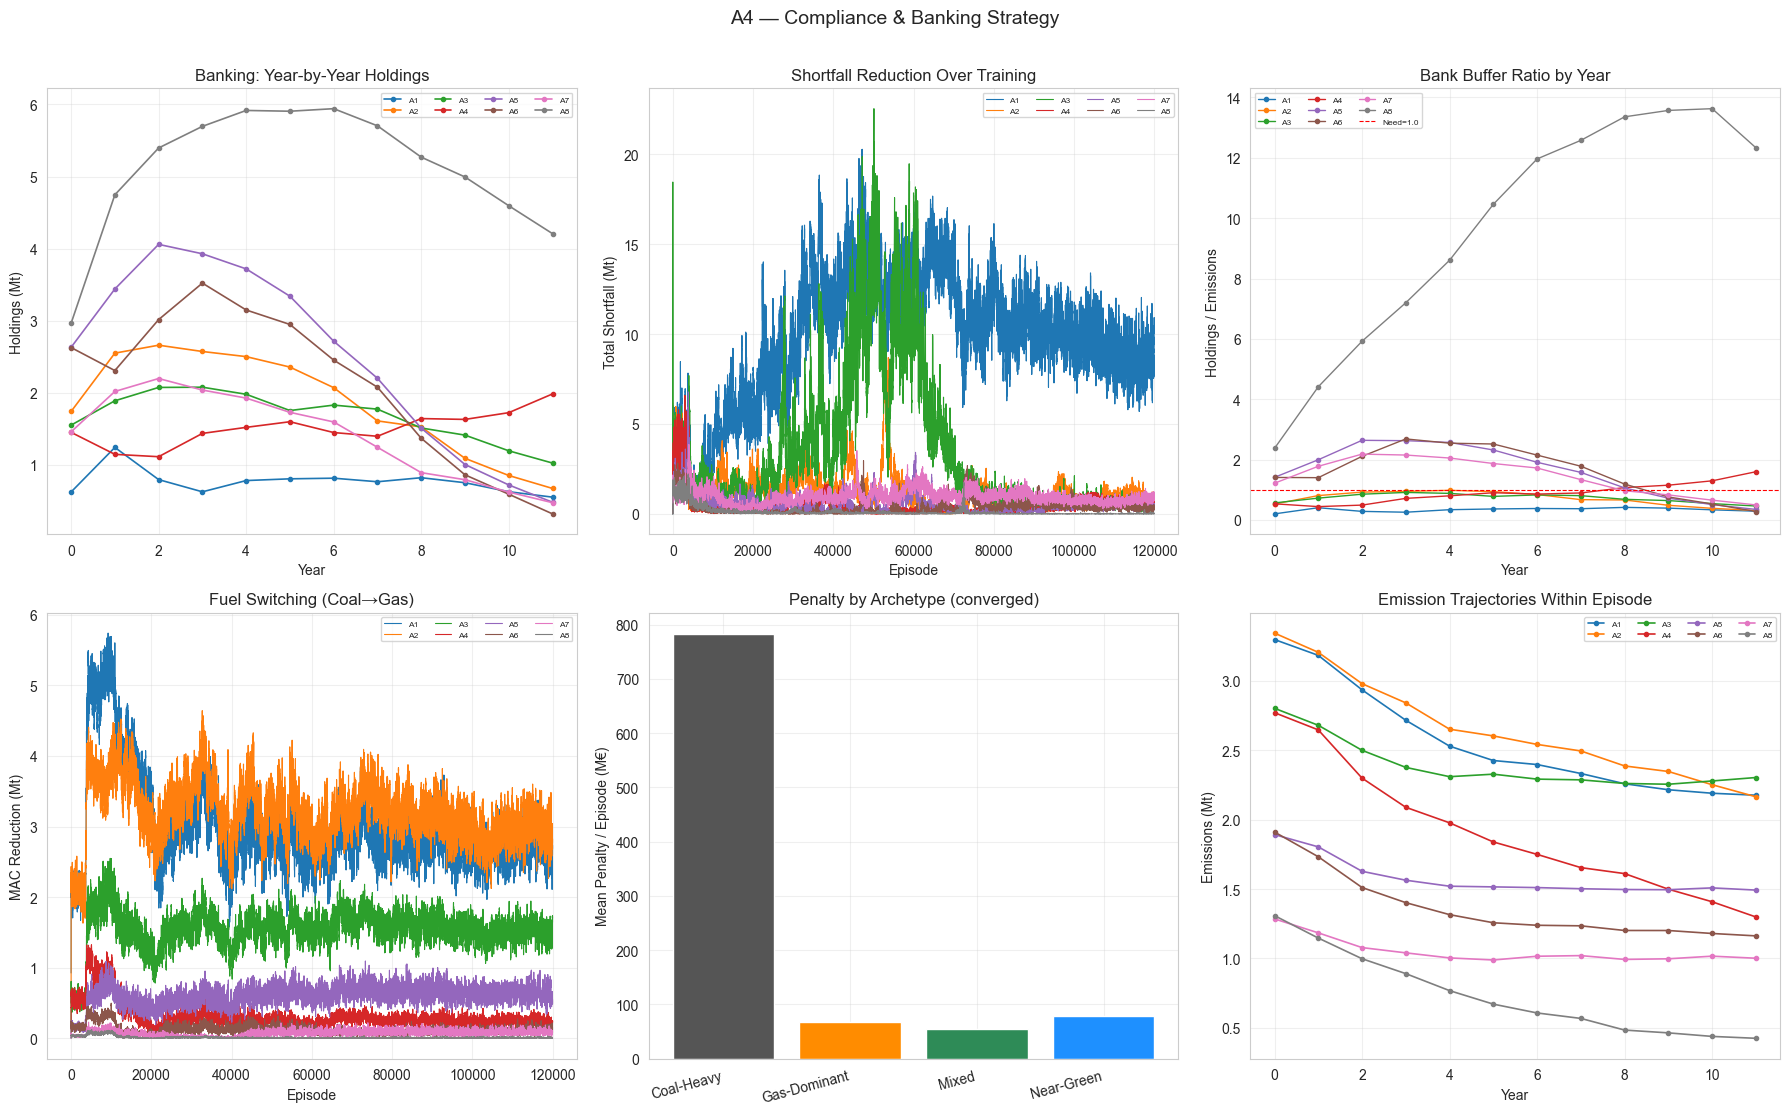

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Holdings trajectory by year
ax = axes[0, 0]
for i in range(n_agents):
    h_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(h_yr.index, h_yr.values, color=agent_colors[i], marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set(xlabel='Year', ylabel='Holdings (Mt)', title='Banking: Year-by-Year Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Shortfall per agent over training
ax = axes[0, 1]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'shortfall_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set(xlabel='Episode', ylabel='Total Shortfall (Mt)', title='Shortfall Reduction Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Bank buffer ratio (holdings / emissions) by year
ax = axes[0, 2]
for i in range(n_agents):
    buffer = (recent_yr[f'holdings_A{i+1}'] / recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)).dropna()
    buf_yr = buffer.groupby(recent_yr.loc[buffer.index, 'year']).mean()
    ax.plot(buf_yr.index, buf_yr.values, color=agent_colors[i], marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Need=1.0')
ax.set(xlabel='Year', ylabel='Holdings / Emissions', title='Bank Buffer Ratio by Year')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — MAC fuel-switching usage
ax = axes[1, 0]
mac_cols_ep = [f'total_mac_reduction_A{i+1}' for i in range(n_agents) if f'total_mac_reduction_A{i+1}' in ep_df.columns]
if mac_cols_ep:
    for i, col in enumerate(mac_cols_ep):
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
    ax.set(xlabel='Episode', ylabel='MAC Reduction (Mt)', title='Fuel Switching (Coal→Gas)')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'MAC data not available', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Penalty by archetype
ax = axes[1, 1]
pen_by_arch = {}
for i in range(n_agents):
    arch = agent_labels[i].split('(')[1].rstrip(')') if '(' in agent_labels[i] else f'A{i+1}'
    pen_by_arch.setdefault(arch, []).append(recent_ep[f'penalty_A{i+1}'].mean())
arch_names = list(pen_by_arch.keys())
ax.bar(arch_names, [np.mean(v) for v in pen_by_arch.values()],
       color=['#555555', '#FF8C00', '#2E8B57', '#1E90FF'][:len(arch_names)])
ax.set(ylabel='Mean Penalty / Episode (M€)', title='Penalty by Archetype (converged)')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right'); ax.grid(True, alpha=0.3)

# 6 — Emissions trajectory by year
ax = axes[1, 2]
for i in range(n_agents):
    em_yr = recent_yr.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(em_yr.index, em_yr.values, color=agent_colors[i], marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set(xlabel='Year', ylabel='Emissions (Mt)', title='Emission Trajectories Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A4 — Compliance & Banking Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A5. Reward Decomposition & Cost Structure

Decompose the per-agent reward into its main cost components. The
cost-breakdown panel now folds in **collateral cost** alongside the four
original components (auction, secondary, investment, penalty). Older logs
without `collateral_cost_A*` columns simply skip that layer.


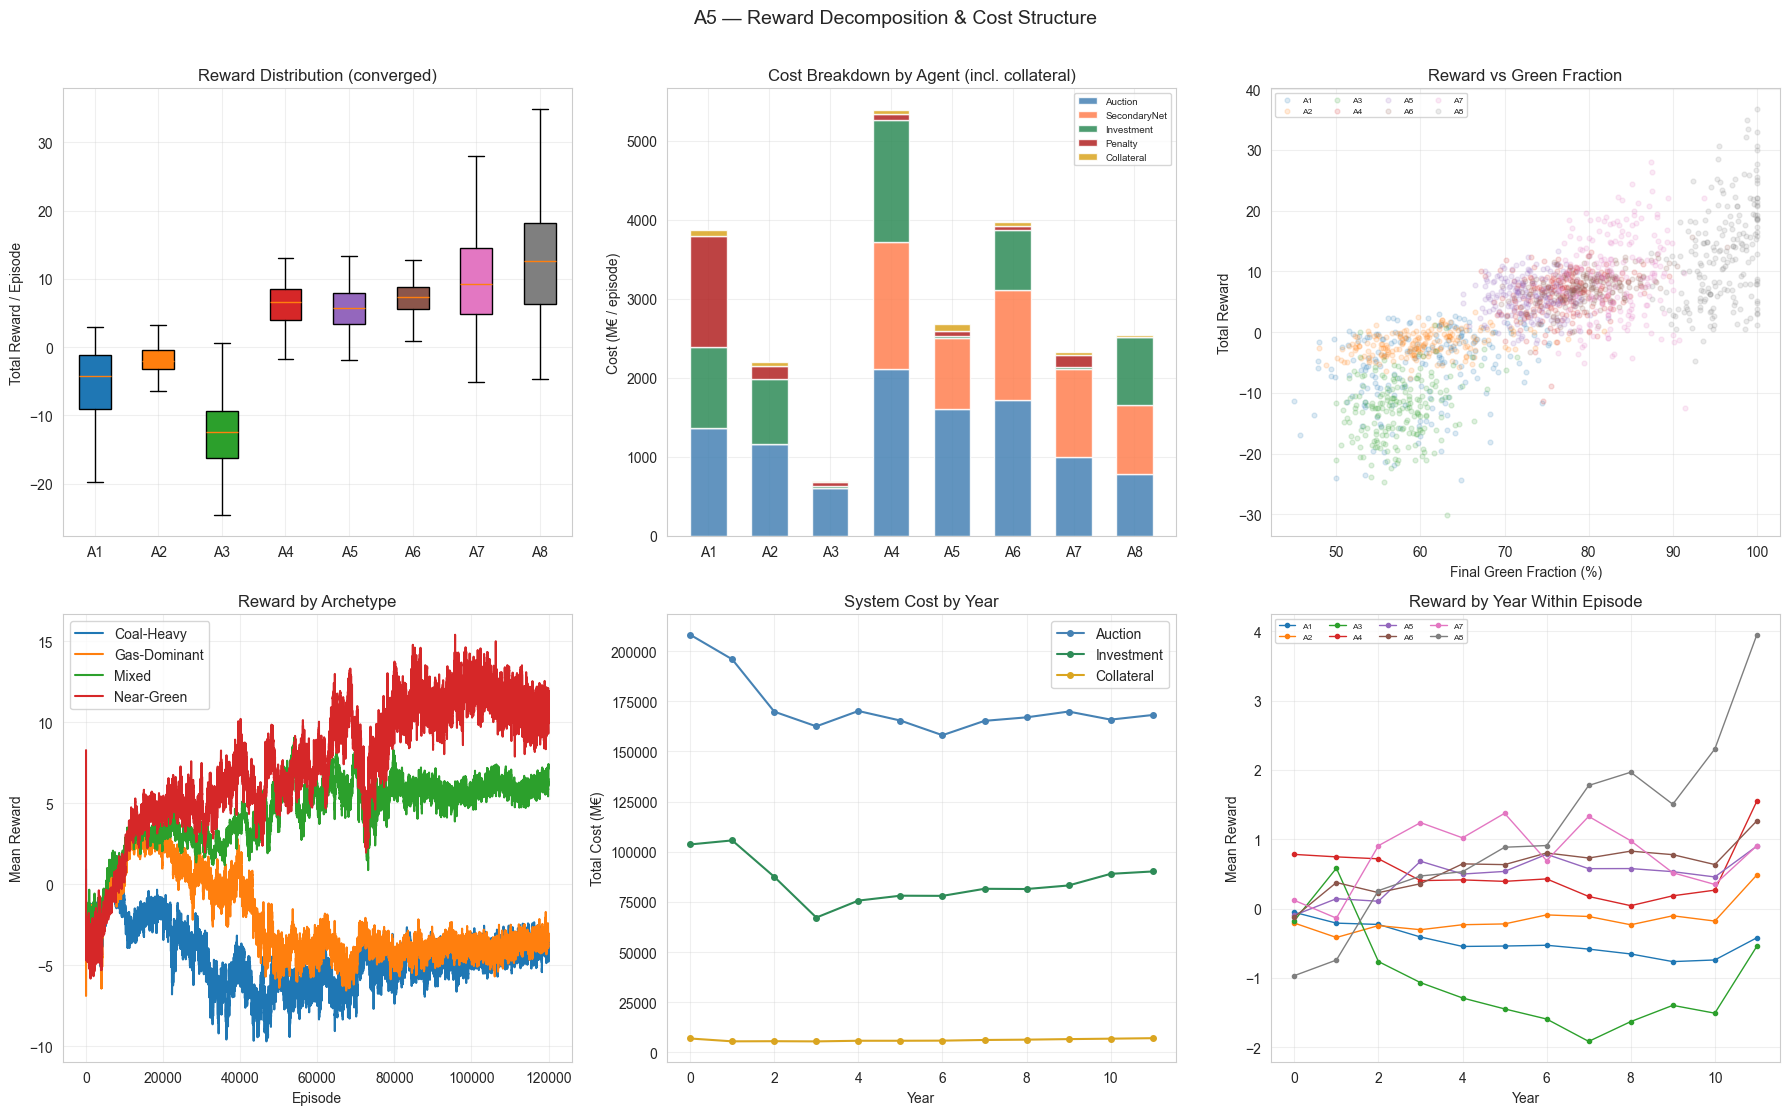

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Reward distribution (converged)
ax = axes[0, 0]
rew_data = [recent_ep[f'reward_A{i+1}'].values for i in range(n_agents) if f'reward_A{i+1}' in recent_ep.columns]
if rew_data:
    bp = ax.boxplot(rew_data, tick_labels=[f'A{i+1}' for i in range(len(rew_data))], patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']): patch.set_facecolor(agent_colors[i])
ax.set(ylabel='Total Reward / Episode', title='Reward Distribution (converged)'); ax.grid(True, alpha=0.3)

# 2 — Cost breakdown (auction / sec / invest / penalty / collateral)
ax = axes[0, 1]
cost_components = {}
for comp, col_tmpl in [('Auction', 'auction_cost_A{}'), ('SecondaryNet', 'secondary_net_A{}'),
                       ('Investment', 'invest_cost_A{}'), ('Penalty', 'penalty_A{}'),
                       ('Collateral', 'collateral_cost_A{}')]:
    cost_components[comp] = [recent_yr.groupby('episode')[col_tmpl.format(i+1)].sum().mean()
                             if col_tmpl.format(i+1) in recent_yr.columns else 0 for i in range(n_agents)]
x = np.arange(n_agents); bottom = np.zeros(n_agents)
comp_colors = {'Auction': 'steelblue', 'SecondaryNet': 'coral', 'Investment': 'seagreen',
               'Penalty': 'firebrick', 'Collateral': 'goldenrod'}
for comp, vals in cost_components.items():
    vals_pos = np.maximum(vals, 0)
    ax.bar(x, vals_pos, 0.6, bottom=bottom, label=comp, color=comp_colors[comp], alpha=0.85)
    bottom += vals_pos
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set(ylabel='Cost (M€ / episode)', title='Cost Breakdown by Agent (incl. collateral)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 3 — Reward vs green fraction
ax = axes[0, 2]
for i in range(n_agents):
    if f'reward_A{i+1}' not in recent_ep.columns: continue
    ax.scatter(recent_ep[f'green_frac_A{i+1}'] * 100, recent_ep[f'reward_A{i+1}'],
               alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set(xlabel='Final Green Fraction (%)', ylabel='Total Reward', title='Reward vs Green Fraction')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Reward by archetype over training
ax = axes[1, 0]
n_per_arch = max(1, n_agents // 4)
for a_idx, arch in enumerate(_base_archetypes):
    agent_ids = list(range(a_idx * n_per_arch, min((a_idx + 1) * n_per_arch, n_agents)))
    if not agent_ids: continue
    arch_rew = sum(ep_df[f'reward_A{i+1}'] for i in agent_ids if f'reward_A{i+1}' in ep_df.columns) / len(agent_ids)
    if isinstance(arch_rew, pd.Series):
        ax.plot(ep_df['episode'], arch_rew.rolling(ROLL, min_periods=1).mean(), lw=1.5, label=arch)
ax.set(xlabel='Episode', ylabel='Mean Reward', title='Reward by Archetype'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — System cost by year
ax = axes[1, 1]
for comp, col_tmpl, color in [('Auction', 'auction_cost_A{}', 'steelblue'),
                              ('Investment', 'invest_cost_A{}', 'seagreen'),
                              ('Collateral', 'collateral_cost_A{}', 'goldenrod')]:
    cols = [col_tmpl.format(i+1) for i in range(n_agents) if col_tmpl.format(i+1) in recent_yr.columns]
    if not cols: continue
    by_yr = recent_yr.groupby('year')[cols].sum().sum(axis=1)
    ax.plot(by_yr.index, by_yr.values, marker='o', ms=4, lw=1.5, color=color, label=comp)
ax.set(xlabel='Year', ylabel='Total Cost (M€)', title='System Cost by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Reward per year within episode
ax = axes[1, 2]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    if col not in recent_yr.columns: continue
    rew_yr = recent_yr.groupby('year')[col].mean()
    ax.plot(rew_yr.index, rew_yr.values, color=agent_colors[i], marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.set(xlabel='Year', ylabel='Mean Reward', title='Reward by Year Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A5 — Reward Decomposition & Cost Structure', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A6. Deterministic Evaluation of Best Agents (optional)

Loads the best checkpoint of each agent for the chosen `(variant, seed)`
and runs one deterministic episode. Skip with `RUN_A6_EVAL = False` if
the sweep was run on a remote machine and only CSV logs are available
locally — A6 is the only deep-dive cell that needs the actual environment.


In [32]:
RUN_A6_EVAL = True

if not RUN_A6_EVAL:
    print('A6 skipped (RUN_A6_EVAL=False).')
else:
    import numpy as np
    from src.environment.ets_environment import ETSEnvironment
    from scripts.train import build_agents

    # Resolve checkpoint dir: tagged sweep dir, then untagged legacy.
    variant_dir = Path(_run['training_log']).parent
    ckpt_dir = next((p for p in [variant_dir / f'checkpoints_{PICK_VARIANT}_s{PICK_SEED}',
                                  variant_dir / f'checkpoints_s{PICK_SEED}'] if p.exists()), None)
    if ckpt_dir is None:
        print(f'No checkpoint directory found under {variant_dir}.')
    else:
        print(f'Loading best checkpoints from: {ckpt_dir}')
        eval_env = ETSEnvironment(config, seed=0)
        eval_agents = build_agents(eval_env, config, seed=0)
        tech_names = config['technologies']['names']

        for i, agent in enumerate(eval_agents):
            ckpt_path = ckpt_dir / f'agent_{i}_best.pt'
            if ckpt_path.exists():
                agent.load(str(ckpt_path)); print(f'  loaded agent {i}')
            else:
                print(f'  no checkpoint for agent {i} ({ckpt_path.name})')

        obs1, _ = eval_env.reset(seed=0)
        eval_data = []
        for year in range(config['simulation']['n_years']):
            auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
            for i in range(n_agents):
                auction_actions[i], _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
            obs2, _ = eval_env.step_auction(auction_actions)
            secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
            for i in range(n_agents):
                secondary_actions[i], _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
            obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
            log = info['year_log']
            row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price'],
                   'secondary_price': log.get('secondary_clearing', 0), 'tnac': log.get('tnac', 0)}
            for i in range(n_agents):
                row[f'green_A{i+1}'] = log['green_fracs'][i]
                row[f'emissions_A{i+1}'] = log['emissions'][i]
                row[f'alloc_A{i+1}'] = log['allocations'][i]
                row[f'holdings_A{i+1}'] = log['holdings'][i]
                row[f'trade_qty_A{i+1}'] = log['trade_qtys'][i]
                row[f'shortfall_A{i+1}'] = log['shortfalls'][i]
                row[f'reward_A{i+1}'] = log['rewards'][i]
                row[f'invest_cost_A{i+1}'] = log['invest_costs'][i]
                for t in range(5):
                    row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
            eval_data.append(row)
            if terminated: break

        eval_df = pd.DataFrame(eval_data)
        print(f'Deterministic evaluation: {len(eval_df)} years')
        display(eval_df[['year', 'cap', 'price', 'secondary_price', 'tnac']])

        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        ax = axes[0, 0]
        ax.plot(eval_df['year'], eval_df['price'], 'b-o', ms=4, label='Auction', lw=1.5)
        ax.plot(eval_df['year'], eval_df['secondary_price'], 'r-s', ms=4, label='Secondary', lw=1.5)
        ax.set(xlabel='Year', ylabel='Price (€/t)', title='Price Trajectories'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[0, 1]
        for i in range(n_agents):
            ax.plot(eval_df['year'], eval_df[f'trade_qty_A{i+1}'], color=agent_colors[i], marker='o', ms=3, lw=1, label=f'A{i+1}')
        ax.axhline(0, color='black', lw=0.5)
        ax.set(xlabel='Year', ylabel='Trade Qty (Mt)', title='Secondary Trade Patterns')
        ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

        ax = axes[0, 2]
        for i in range(n_agents):
            ax.plot(eval_df['year'], eval_df[f'holdings_A{i+1}'], color=agent_colors[i], marker='o', ms=3, lw=1, label=f'A{i+1}')
        ax.set(xlabel='Year', ylabel='Holdings (Mt)', title='Banking: Allowance Holdings')
        ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

        ax = axes[1, 0]
        for i in range(n_agents):
            ax.plot(eval_df['year'], eval_df[f'emissions_A{i+1}'], color=agent_colors[i], lw=1.2)
            ax.plot(eval_df['year'], eval_df[f'alloc_A{i+1}'], color=agent_colors[i], ls='--', lw=0.8, alpha=0.6)
        ax.set(xlabel='Year', ylabel='Mt', title='Emissions (solid) vs Allocation (dashed)'); ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        for i in range(n_agents):
            ax.plot(eval_df['year'], eval_df[f'green_A{i+1}'] * 100, color=agent_colors[i], marker='o', ms=3, lw=1.2, label=f'A{i+1}')
        ax.set(xlabel='Year', ylabel='Green Fraction (%)', title='Green Transition')
        ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

        ax = axes[1, 2]
        for i in range(n_agents):
            ax.plot(eval_df['year'], eval_df[f'reward_A{i+1}'].cumsum(), color=agent_colors[i], lw=1.5, label=f'A{i+1}')
        ax.set(xlabel='Year', ylabel='Cumulative Reward', title='Cumulative Reward')
        ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

        plt.suptitle('A6 — Deterministic Evaluation', fontsize=14, y=1.01)
        plt.tight_layout(); plt.show()


No checkpoint directory found under C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\sweeps\default.
